In [43]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

import networkx as nx
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from vizman import viz
viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

from src.visualization.one_simple_plot import plot_one_aesthetic_plot

In [44]:
lecker_red = default_colors["warms"]["LECKER_RED"]
bone_white = default_colors["neutrals"]["BONE_WHITE"]
olive_gray = default_colors["neutrals"]["OLIVE_GRAY"]

In [45]:
dataset_name = "lexis_data" # "suarez_MaMI_dataset"
experiment_name = "01_ring_sweep_animal_0" # "95_ring_seed_100_sweep_animal_206"

base_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name}")
save_path = base_path / f"all_metrics_for_{experiment_name}.csv"

In [46]:
def plot_comparison_landscape(mode):     
    path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name}/summary_indiv_{mode}_for_exp_{experiment_name}.csv"
    df = pd.read_csv(path)
    print(df.keys())
    
    # get the column name that is not "eta" or "gamma"
    metric_col = [col for col in df.columns if col not in ["eta", "gamma", "network_index", "filename", "id"]]
    if not metric_col:
        raise ValueError(f"No metric column found in {df.columns}")

    print("Metric column:", metric_col[0])
    
    fig, ax = plot_one_aesthetic_plot(df["eta"], 
                            df["gamma"], 
                            df[metric_col[0]],
                            save_path=None, 
                            dot_color=lecker_red,  
                            cmap=default_cmaps["metric_purple_beige"],
                            point_size=2,
                            mark_minimum_point=True, 
                            title=f"{metric_col[0].split('subject')[0].replace('_', ' ').capitalize()}\nlandscape for {experiment_name.replace('_', ' ')}")
    
    return fig, ax
    # plt.show()

In [47]:
all_methods = ["f1", 
        "portrait",  
        "communicability", 
        "delta_con", 
        "spectral_distance",
        "edit_distance", 
        "cosine_embedding", 
        "wasserstein_gromov",
        "wasserstein_sinkhorn", 
        "hungarian_alignment", 
        "graph_kernel", 
        "graph_kernel_networkx", 
        "multiplex_layer_similarity", 
        "resistance_distance", 
        "graph_edit_distance", 
        "network_mutual_information", 
        "communicability_mse", 
        "communicability_jsd", 
        "frobenius", 
        "jaccard", 
        "energy"]

method_names = {
    'portrait': 'Portrait Divergence',
    'energy': 'Energy Distance',
    'spectral_distance': 'Spectral Distance',
    'f1': 'F1 Score',
    'communicability': 'Communicability Distance',
    'graph_kernel': 'Graph Kernel Distance',
    'multiplex_layer_similarity': 'Multiplex Layer Similarity',
    'cosine_embedding': 'Cosine Embedding Distance',
    'graph_edit_distance': 'Graph Edit Distance',
    'network_mutual_information': 'Network Mutual Information',
    'hungarian_alignment': 'Hungarian Alignment',
    'graph_kernel_networkx': 'Graph Kernel (NetworkX)',
    'delta_con': 'DeltaCon',
    'resistance_distance': 'Resistance Distance',
    'wasserstein_gromov': 'Wasserstein-Gromov',
    'wasserstein_sinkhorn': 'Wasserstein-Sinkhorn', 

    'edit_distance': 'Edit Distance',
    'communicability_mse': 'Communicability MSE',
    'communicability_jsd': 'Communicability JSD',
    'frobenius': 'Frobenius Distance',
    'jaccard': 'Jaccard Distance'
}

# Individual heatmaps (works like a charm) 
# for m in all_methods:
#     plot_comparison_landscape(m)

metric_colors = {}
colors = sns.color_palette("tab20", len(method_names.values())) # husl
for i, (metric_name, metric_label) in enumerate(zip(method_names.keys(), method_names.values())):
    metric_colors[metric_name] = colors[i]


# Further grid plots

In [48]:
# Add: Averaging over 10 runs! 

f1
portrait
communicability
delta_con
spectral_distance
edit_distance
cosine_embedding
wasserstein_gromov
wasserstein_sinkhorn
hungarian_alignment
graph_kernel
graph_kernel_networkx
multiplex_layer_similarity
resistance_distance
graph_edit_distance
network_mutual_information
communicability_mse
communicability_jsd
frobenius
jaccard
energy


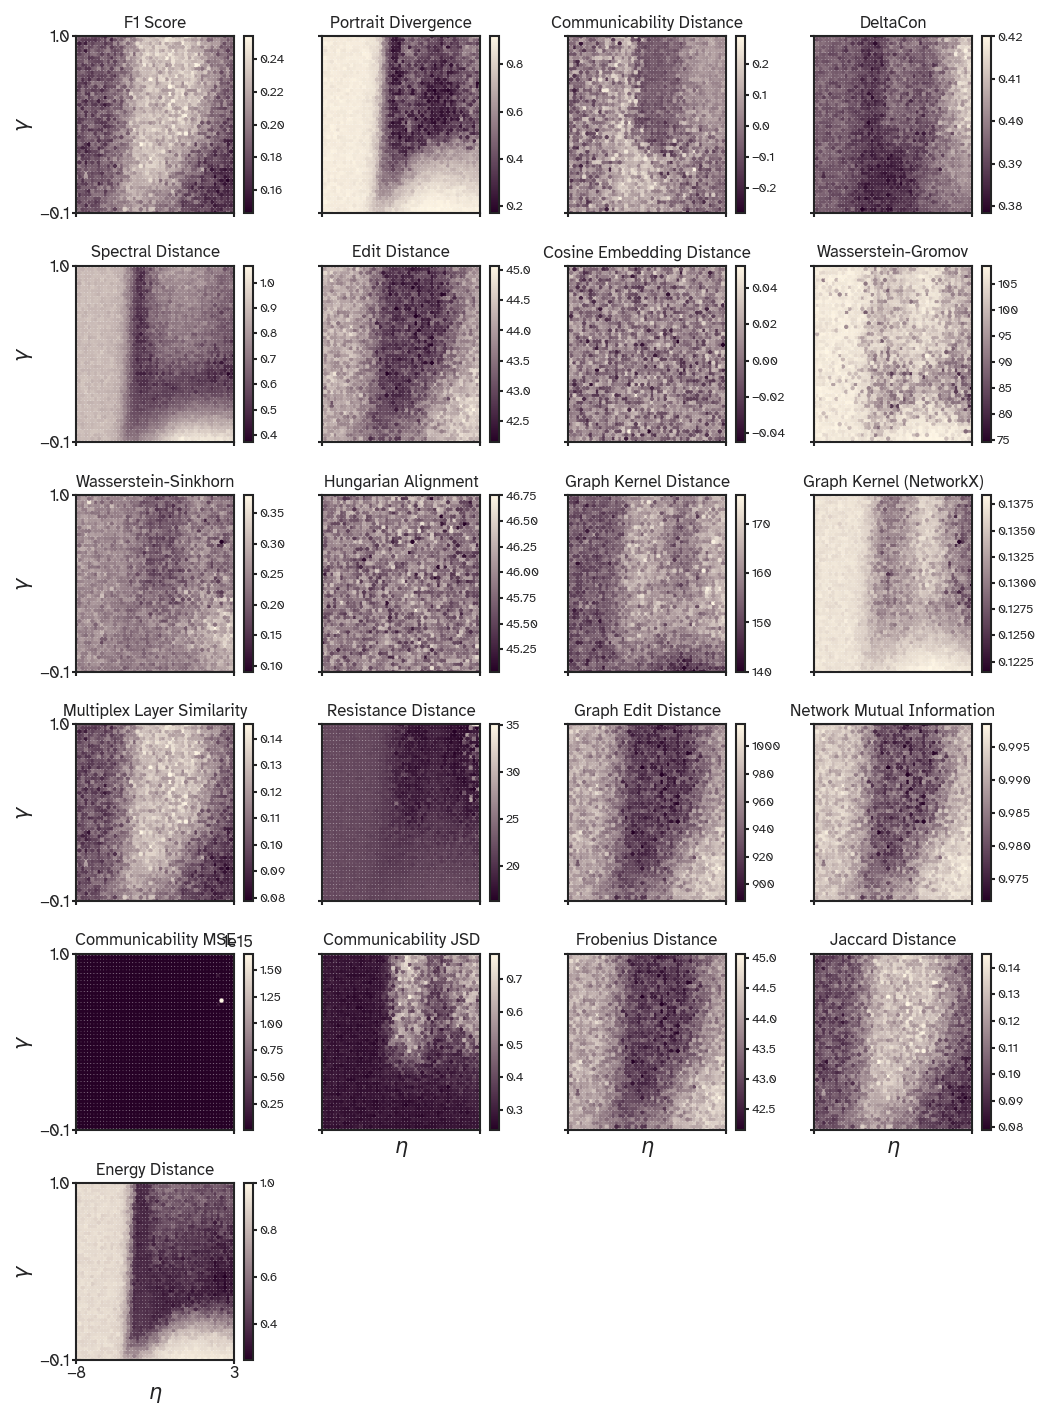

In [49]:
def plot_comparison_landscape_grid(all_methods, dataset_name, experiment_name):
    """
    Plot all methods in a 4x4 grid with shared axes and individual colorbars.
    """
    n_methods = len(all_methods)
    n_cols = 4
    n_rows = int(np.ceil(n_methods / n_cols))
    
    # Calculate height to maintain roughly square subplots
    height = 18 * (n_rows / n_cols) * 0.9 # 0.9 is random factor for colorbar
    
    fig, axes = plt.subplots(n_rows, n_cols, 
                             figsize=viz.cm_to_inch((18, height)), 
                             dpi=150,
                             sharex=True, 
                             sharey=True)
    
    axes = axes.flatten()
    
    for idx, mode in enumerate(all_methods):
        ax = axes[idx]
        
        path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name}/summary_indiv_{mode}_for_exp_{experiment_name}.csv"
        df = pd.read_csv(path)
        
        # Get the metric column
        metric_col = [col for col in df.columns if col not in ["eta", "gamma", "network_index", "filename", "id"]]
        if not metric_col:
            raise ValueError(f"No metric column found in {df.columns}")
        
        # Create scatter plot
        scatter = ax.scatter(df["eta"], df["gamma"], 
                            c=df[metric_col[0]], 
                            cmap=default_cmaps["metric_purple_beige"], 
                            s=1.2)
        
        ax.set_xlim(-8, 3)
        ax.set_ylim(-0.1, 1)
        
        # Set ticks
        ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
        ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        
        # Add title for each subplot
        print(mode)
        title = method_names[mode] # f"{metric_col[0].split('subject')[0].replace('_', ' ').capitalize()}"
        ax.set_title(title, fontsize=8)
        
        # Add colorbar for each subplot
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.ax.tick_params(labelsize=6)
        
        # Only add labels to edge subplots
        if idx % n_cols == 0:  # Left column
            ax.set_ylabel(r"$\gamma$")
        if idx >= n_methods - n_cols:  # Bottom row
            ax.set_xlabel(r"$\eta$")
    
    # Hide unused subplots
    for idx in range(n_methods, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    
    return fig, axes


# Usage
fig, axes = plot_comparison_landscape_grid(all_methods, dataset_name, experiment_name)
plt.show()

# Timing 

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/1311140973.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(timing_data,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/1311140973.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(timing_data,


(<Figure size 354.331x472.441 with 1 Axes>,
 <Axes: title={'center': 'Timing Comparison Across Methods'}, ylabel='Time (seconds)'>)

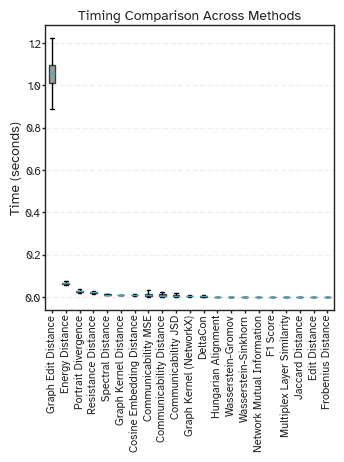

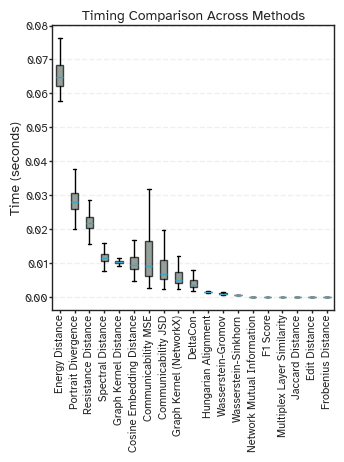

In [50]:
def create_timing_boxplot_comparison(base_path, exp_name, all_methods, cutoff=None, order_by_median=True):
   
    timing_data = []
    method_labels = []
    
    for method in all_methods:
        # Construct the timing file path
        timing_file = Path(base_path) / f"timing_{method}_for_exp_{exp_name}.csv"
        
        # Check if file exists
        if not timing_file.exists():
            print(f"Warning: File not found - {timing_file}")
            continue
        
        # Read timing data
        df = pd.read_csv(timing_file)
        
        # Find the timing column
        timing_col = None
        for col in df.columns:
            if any(keyword in col.lower() for keyword in ['time']):
                timing_col = col
                break
        
        # Extract timing values
        timings = df[timing_col].dropna().values
        
        if len(timings) > 0:
            timing_data.append(timings)
            method_labels.append(method_names[method]) # .replace("_", " ").title())
    
    # Order methods by median timing
    if order_by_median:
        median_timings = [np.median(data) for data in timing_data]
        sorted_indices = np.argsort(median_timings)[::-1]
        timing_data = [timing_data[i] for i in sorted_indices]
        method_labels = [method_labels[i] for i in sorted_indices]
    
    # Create boxplot
    fig, ax = plt.subplots(figsize=viz.cm_to_inch((9,12))) # (8, 8))
    
    bp = ax.boxplot(timing_data, 
                    labels=method_labels,
                    patch_artist=True,
                    showmeans=False, # True,
                    showfliers=False 
                    # meanprops=dict(marker='D', markerfacecolor='red', markersize=3)
    ) 
    
    # Customize appearance
    for patch in bp['boxes']:
        # patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    
    ax.set_ylabel('Time (seconds)') # , fontsize=12, fontweight='bold')
    # ax.set_xlabel('Method') # , fontsize=12, fontweight='bold')
    ax.set_title(f'Timing Comparison Across Methods') # \n{exp_name}') 
                #  fontsize=14, fontweight='bold', pad=20)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=90, ha='center') # right')
    
    # Add grid for better readability
    ax.yaxis.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Log scale option (uncomment if timing spans multiple orders of magnitude)
    # ax.set_yscale('log')
    # ax.set_ylabel('Time (seconds, log scale)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    
    return fig, ax


selected_methods = all_methods
create_timing_boxplot_comparison(base_path, experiment_name, selected_methods, cutoff=None, order_by_median=True)
selected_methods = set(all_methods) - set(["graph_edit_distance", "communicability"])
create_timing_boxplot_comparison(base_path, experiment_name, selected_methods, cutoff=None, order_by_median=True)

# Correlation Matrix 

In [51]:
output_path = Path(base_path) / "ground_truth_analysis"
output_path.mkdir(exist_ok=True)

In [52]:

def load_method_data(method):
    """Load data for a specific method."""
    path = f"{base_path}/summary_indiv_{method}_for_exp_{experiment_name}.csv"
    try:
        df = pd.read_csv(path)
        metric_cols = [col for col in df.columns 
                      if col not in ["eta", "gamma", "network_index", "filename", "id"]]
        if metric_cols:
            df['metric_value'] = df[metric_cols[0]]
            df['method'] = method
            return df[['eta', 'gamma', 'id', 'metric_value', 'method']]
        return None
    except FileNotFoundError:
        print(f"Warning: File not found for method {method}")
        return None

def calculate_ground_truth(all_data):
    """Calculate approximated ground truth as max across methods for each eta-gamma-id."""
    ground_truth = all_data.groupby(['eta', 'gamma', 'id'])['metric_value'].max().reset_index()
    ground_truth.rename(columns={'metric_value': 'approximated_ground_truth'}, inplace=True)
    return ground_truth

def create_full_dataset(all_data, ground_truth):
    """Create dataset with all methods and ground truth."""
    pivot_data = all_data.pivot_table(
        index=['eta', 'gamma', 'id'],
        columns='method',
        values='metric_value'
    ).reset_index()
    
    if ground_truth is not None:
        full_data = pivot_data.merge(ground_truth, on=['eta', 'gamma', 'id'])
    else: 
        full_data = pivot_data
    return full_data

def calculate_correlation_matrix(full_data, methods):
    """Calculate Pearson correlation matrix between methods and ground truth."""
    cols_to_correlate = methods # + ['approximated_ground_truth']
    corr_matrix = full_data[cols_to_correlate].corr(method='pearson')
    return corr_matrix

def cluster_correlation_matrix(corr_matrix):
    """
    Cluster the correlation matrix using hierarchical clustering.
    Returns the reordered correlation matrix and the order of items.
    """
    # Convert correlation to distance
    # Use 1 - correlation for positive correlations (closer to 1 = more similar)
    distance_matrix = 1 - corr_matrix.values
    
    # Ensure all values are non-negative and clip to avoid numerical issues
    distance_matrix = np.clip(distance_matrix, 0, 2)
    
    # Make sure the matrix is symmetric
    distance_matrix = (distance_matrix + distance_matrix.T) / 2
    
    # Set diagonal to 0
    np.fill_diagonal(distance_matrix, 0)
    
    # Convert to condensed distance matrix
    condensed_dist = squareform(distance_matrix, checks=False)
    
    # Replace any NaN or inf values
    condensed_dist = np.nan_to_num(condensed_dist, nan=1.0, posinf=2.0, neginf=0.0)
    
    # Perform hierarchical clustering
    linkage_matrix = linkage(condensed_dist, method='average')  # Changed to 'average' which is more robust
    
    # Get the order from the dendrogram
    dendro = dendrogram(linkage_matrix, no_plot=True)
    order = dendro['leaves']

    # Reorder the correlation matrix
    ordered_corr = corr_matrix.iloc[order, order]
    
    return ordered_corr, order, linkage_matrix


In [53]:
print("Loading method data...")
all_data_list = []
loaded_methods = []

for method in all_methods:
    df = load_method_data(method)
    if df is not None:
        all_data_list.append(df)
        loaded_methods.append(method)
        print(f"  ✓ Loaded {method}: {len(df)} rows")

if not all_data_list:
    print("Error: No method data could be loaded!")
    
all_data = pd.concat(all_data_list, ignore_index=True)
print(f"\nCombined data: {len(all_data)} total rows")

print("\nCalculating approximated ground truth...")
# ground_truth = calculate_ground_truth(all_data)
# print(f"  Ground truth calculated for {len(ground_truth)} unique eta-gamma-id combinations")

print("\nCreating full dataset with all methods...")
full_data = create_full_dataset(all_data, ground_truth=None)
# print(f"  Full dataset shape: {full_data.shape}")

# gt_path = output_path / 'approximated_ground_truth.csv'
# ground_truth.to_csv(gt_path, index=False)
# print(f"\n✓ Saved approximated ground truth to {gt_path}")

# full_path = output_path / 'full_dataset_with_ground_truth.csv'
# full_data.to_csv(full_path, index=False)
# print(f"✓ Saved full dataset to {full_path}")

print("\nCalculating Pearson correlation matrix...")
corr_matrix = calculate_correlation_matrix(full_data, loaded_methods)

corr_path = output_path / 'correlation_matrix.csv'
corr_matrix.to_csv(corr_path)
print(f"✓ Saved correlation matrix to {corr_path}")

# print("\nCorrelations with Approximated Ground Truth (Pearson):")
# # gt_corrs = corr_matrix['approximated_ground_truth'].drop('approximated_ground_truth').sort_values(ascending=False)
# # gt_corrs = corr_matrix['approximated_ground_truth'].drop('approximated_ground_truth').sort_values(ascending=False)
# for method, corr in gt_corrs.items():
#     print(f"  {method:30s}: {corr:6.3f}")



Loading method data...
  ✓ Loaded f1: 2500 rows
  ✓ Loaded portrait: 2500 rows
  ✓ Loaded communicability: 2500 rows
  ✓ Loaded delta_con: 2500 rows
  ✓ Loaded spectral_distance: 2500 rows
  ✓ Loaded edit_distance: 2500 rows
  ✓ Loaded cosine_embedding: 2500 rows
  ✓ Loaded wasserstein_gromov: 2500 rows
  ✓ Loaded wasserstein_sinkhorn: 2500 rows
  ✓ Loaded hungarian_alignment: 2500 rows
  ✓ Loaded graph_kernel: 2500 rows
  ✓ Loaded graph_kernel_networkx: 2500 rows
  ✓ Loaded multiplex_layer_similarity: 2500 rows
  ✓ Loaded resistance_distance: 2500 rows
  ✓ Loaded graph_edit_distance: 2500 rows
  ✓ Loaded network_mutual_information: 2500 rows
  ✓ Loaded communicability_mse: 2500 rows
  ✓ Loaded communicability_jsd: 2500 rows
  ✓ Loaded frobenius: 2500 rows
  ✓ Loaded jaccard: 2500 rows
  ✓ Loaded energy: 2500 rows

Combined data: 52500 total rows

Calculating approximated ground truth...

Creating full dataset with all methods...

Calculating Pearson correlation matrix...
✓ Saved corre

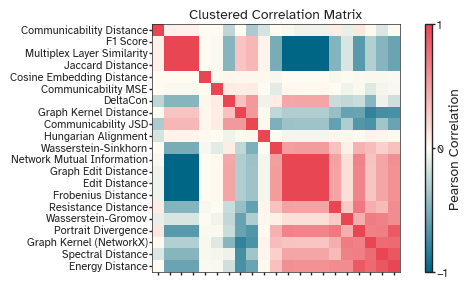

Saved clustered correlation heatmap to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/01_ring_sweep_animal_0/ground_truth_analysis/correlation_heatmap_clustered.png


In [54]:

def plot_clustered_correlation_heatmap(corr_matrix, save_path):
    """Plot and save clustered correlation matrix heatmap."""
    # Cluster the correlation matrix
    clustered_corr, order, linkage_matrix = cluster_correlation_matrix(corr_matrix)
    
    # Create figure with dendrogram
    fig = plt.figure(figsize=viz.cm_to_inch((9,9))) # (16, 14)

    
    # Add heatmap
    ax_heatmap = fig.add_axes([0.22, 0.1, 0.7, 0.8])
    sns.heatmap(clustered_corr, annot=False, # True, fmt='.2f', annot_kws={'size': 8},
                cmap=default_cmaps["db_bw_lr"], # 'RdBu_r', 
                # center=0, vmin=-1, vmax=1, 
                square=True,
                cbar=False, 
                # cbar_kws={'label': 'Pearson Correlation'},
                ax=ax_heatmap, 
                # linewidths=0.5
                )

    # Add spines
    for spine in ax_heatmap.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)

    # Get xticklabels, and replace them with their corresponding method names
    method_names_arr = [method_names.get(name, name) for name in clustered_corr.index]
    ax_heatmap.set_yticklabels(method_names_arr) # , rotation=45, ha='right')
    ax_heatmap.set_xticklabels([])# False) # []) # method_names_arr) # , rotation=0)
    ax_heatmap.set_title('Clustered Correlation Matrix') 
    #                      fontsize=16, pad=20)

    ax_heatmap.set_xlabel(None)
    ax_heatmap.set_ylabel(None)
    
    # cbar
    # Add cbar that is as high as the heatmap. So get the lowest and highest position of the heatmap
    highest_pos = ax_heatmap.get_position().y1
    lowest_pos = ax_heatmap.get_position().y0
    buffer = 0.01
    # cbar_ax = fig.add_axes([1, 0.1, 0.02, 0.8])
    cbar_ax = fig.add_axes([1-buffer, lowest_pos, 0.02, highest_pos - lowest_pos])
    norm = plt.Normalize(vmin=clustered_corr.values.min(), vmax=clustered_corr.values.max())
    sm = plt.cm.ScalarMappable(cmap=default_cmaps["db_bw_lr"], norm=norm)
    sm.set_array([])
    
    cbar = plt.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Pearson Correlation') # , fontsize=10)
    # only add ticks for -1, 0, 1
    cbar.set_ticks([-1, 0, 1])
    cbar.ax.tick_params(labelsize=8)
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved clustered correlation heatmap to {save_path}")
    
    return clustered_corr

# Clustered correlation heatmap
heatmap_path = output_path / 'correlation_heatmap_clustered.png'
clustered_corr = plot_clustered_correlation_heatmap(corr_matrix, heatmap_path)


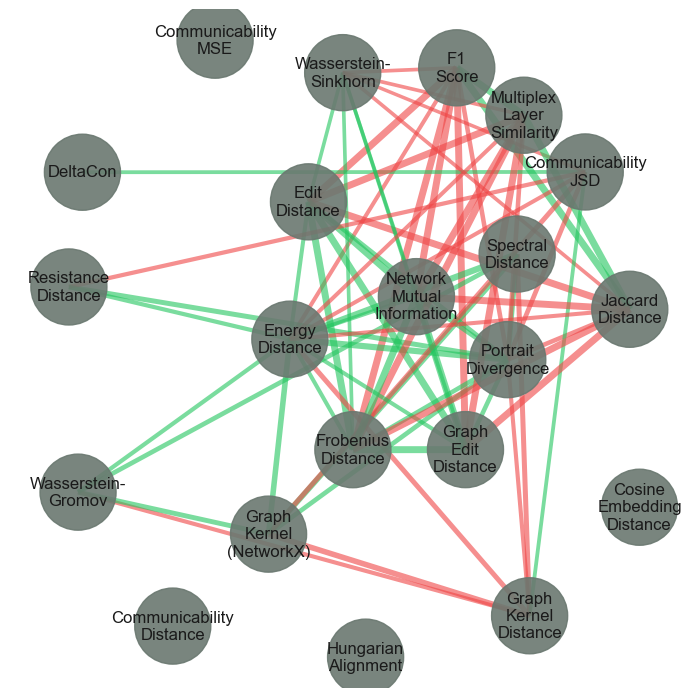

Saved correlation network to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/01_ring_sweep_animal_0/ground_truth_analysis/correlation_network_spring.png

Network Statistics:
  Number of nodes: 21
  Number of edges: 65
  Average degree: 6.19


In [55]:

def plot_correlation_network(corr_matrix, save_path, threshold=0.5):
    """
    Create a network graph where methods are nodes and correlations are edges.
    """
    # Create graph
    G = nx.Graph()
    
    # Add nodes
    methods = corr_matrix.columns.tolist()
    G.add_nodes_from(methods)
    
    # Add edges for correlations above threshold
    for i, method1 in enumerate(methods):
        for j, method2 in enumerate(methods):
            if i < j:  # Avoid duplicate edges
                corr_value = corr_matrix.loc[method1, method2]
                if not np.isnan(corr_value) and abs(corr_value) >= threshold:
                    G.add_edge(method1, method2, weight=abs(corr_value), 
                              correlation=corr_value)
    
    # Create figure
    fig, ax = plt.subplots(figsize=viz.cm_to_inch((18,18)))

    # Use spring layout (Fruchterman-Reingold)
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    
    # Draw nodes
    node_colors = []
    for node in G.nodes():
        if node == 'approximated_ground_truth':
            node_colors.append(lecker_red)  # Red for ground truth
        else:
            node_colors.append(olive_gray) 
    
    # node_sizes = [3000 if node == 'approximated_ground_truth' else 2000 
    #               for node in G.nodes()]
    node_sizes = [3000 for node in G.nodes()]
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                          node_size=node_sizes, alpha=0.9, ax=ax)
    
    # Draw edges with varying thickness and color based on correlation
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    correlations = [G[u][v]['correlation'] for u, v in edges]
    
    # Normalize edge widths
    edge_widths = [w * 5 for w in weights]
    
    # Color edges by positive/negative correlation
    edge_colors = ['#22c55e' if c > 0 else '#ef4444' for c in correlations]
    
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6,
                          edge_color=edge_colors,
                          ax=ax)
    
    # Draw labels
    # labels = {node: node.replace('_', '\n') for node in G.nodes()}
    labels = {node: method_names[node].replace(' ', '\n').replace('-', '-\n') for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, 
                        #     font_size=8, 
                        #    font_weight='bold',
                           ax=ax)
    
    # Add title and legend
    # ax.set_title(f'Method Correlation Network (|r| ≥ {threshold})') 
    ax.axis('off')
    
    # # Create custom legend
    # from matplotlib.lines import Line2D
    # legend_elements = [
    #     Line2D([0], [0], marker='o', color='w', markerfacecolor='#ef4444', 
    #            markersize=15, 
    #            label='Ground Truth'),
    #     Line2D([0], [0], marker='o', color='w', markerfacecolor='#6366f1', 
    #            markersize=12, label='Methods'),
    #     Line2D([0], [0], color='#22c55e', linewidth=3, label='Positive Correlation'),
    #     Line2D([0], [0], color='#ef4444', linewidth=3, label='Negative Correlation'),
    # ]
    # ax.legend(handles=legend_elements, loc='upper right', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved correlation network to {save_path}")
    
    # Print network statistics
    print(f"\nNetwork Statistics:")
    print(f"  Number of nodes: {G.number_of_nodes()}")
    print(f"  Number of edges: {G.number_of_edges()}")
    if G.number_of_nodes() > 0:
        print(f"  Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
    
    return G


# Correlation network graphs
network_path_spring = output_path / 'correlation_network_spring.png'
plot_correlation_network(corr_matrix, network_path_spring, threshold=0.5)



In [56]:
def get_top_networks_distribution(dataset_name, experiment_name, mode='portrait', top_n=20):

    # Paths
    base_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name}"
    summary_path = f"{base_path}/summary_indiv_{mode}_for_exp_{experiment_name}.csv"
    networks_path = f"{base_path}/generated_networks"
    
    # Load summary data
    df = pd.read_csv(summary_path)
    # print(f"Loaded summary with columns: {list(df.columns)}")
    
    # Identify metric column (excluding metadata columns)
    metadata_cols = ["eta", "gamma", "network_index", "filename", "id"]
    metric_cols = [col for col in df.columns if col not in metadata_cols]
    
    if not metric_cols:
        raise ValueError(f"No metric column found in {df.columns}")
    
    metric_col = metric_cols[0]
    print(f"Using metric column: '{metric_col}'")
    
    # Select top N networks (lowest values = best)
    df_sorted = df.nsmallest(top_n, metric_col)
    # print(f"\nSelected top {top_n} networks with {metric_col} range: "
    #       f"[{df_sorted[metric_col].min():.6f}, {df_sorted[metric_col].max():.6f}]")
        
    # Load distance matrix (schaefer) 
    distance_matrix_file = "/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/02_distance_matrices/distance_matrix_100.npy"
    distance_matrix = np.load(distance_matrix_file)
    
    
    # Load networks and calculate degree distributions
    all_degrees = []
    all_distances = []
    
    for idx, row in df_sorted.iterrows():
        # Construct filename
        network_file = Path(networks_path) / row['filename']
        
        # Load network
        network = np.load(network_file)
        
        # Extract adjacency matrix (assuming shape is (1, 100, 100))
        if network.shape[0] == 1:
            adj_matrix = network[0]
        else:
            adj_matrix = network
        
        # Calculate degree for each node
        degrees = np.sum(adj_matrix, axis=1)
        all_degrees.extend(degrees)
        
        # get all distances, remove zeros 
        distances_for_this_network = (distance_matrix*network).flatten()
        all_distances.extend(distances_for_this_network[distances_for_this_network > 0])
        
    # Convert to numpy array
    all_degrees = np.array(all_degrees)
    all_distances = np.array(all_distances)
    # print(f"\nCollected {len(all_degrees)} node degrees from {len(df_sorted)} networks")
    # print(f"Degree statistics: mean={all_degrees.mean():.2f}, "
    #       f"std={all_degrees.std():.2f}, "
    #       f"min={all_degrees.min()}, max={all_degrees.max()}")   

    # Get distance matrix values (excluding zeros on diagonal)
    # all_distances = distance_matrix[distance_matrix > 0]
    
    return all_degrees, all_distances

distributions_degree = {}
distributions_distances = {}
for mode in all_methods: 
    distributions_degree[mode], distributions_distances[mode] = get_top_networks_distribution(dataset_name, experiment_name, mode=mode, top_n=20)


Using metric column: 'F1Crit_subject_0'
Using metric column: 'PortraitDiv_subject_0'
Using metric column: 'CommCorr_subject_0'
Using metric column: 'DeltaCon_exact_subject_0'
Using metric column: 'SpectralDist_normalized_laplacian_subject_0'
Using metric column: 'EditDistance_subject_0'
Using metric column: 'CosineEmb_spectral_subject_0'
Using metric column: 'GW_subject_0'
Using metric column: 'Wasserstein_subject_0'
Using metric column: 'Hungarian_subject_0'
Using metric column: 'GraphKernel_weisfeiler_lehman_subject_0'
Using metric column: 'GraphKernel_random_walk_subject_0'
Using metric column: 'MultiplexSim_jaccard_subject_0'
Using metric column: 'ResistanceDist_exact_subject_0'
Using metric column: 'GraphEditDist_subject_0'
Using metric column: 'NMI_standard_subject_0'
Using metric column: 'CommMSE_subject_0'
Using metric column: 'CommJSD_subject_0'
Using metric column: 'Frobenius_subject_0'
Using metric column: 'Jaccard_subject_0'
Using metric column: 'MaxCrit_subject_0'


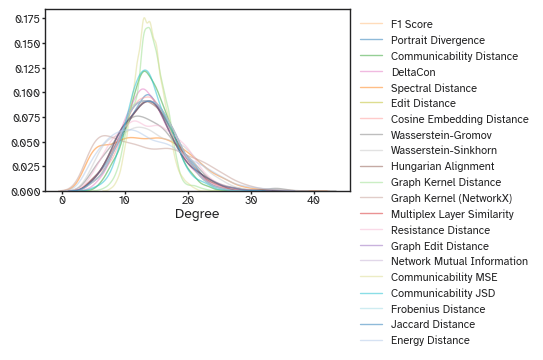

In [57]:
# plot degree distributions (smoothed) 
fig, ax = plt.subplots(figsize=viz.cm_to_inch((10, 6)))
for mode, degrees in distributions_degree.items():
    # Plot histogram with density=True for normalization
    sns.kdeplot(degrees, 
                label=method_names[mode], # .replace('_', ' ').title(), 
                color=metric_colors[mode],
                ax=ax, 
                fill=False, # True, 
                alpha=0.5)
    # plt.legend(fontsize=8)
    plt.xlabel('Degree')
    plt.ylabel("") # 'Density')
    # Put the legend outside the plot, completely. 
    plt.legend(fontsize=8, 
               # loc='upper right', 
               bbox_to_anchor=(1, 1), frameon=False)

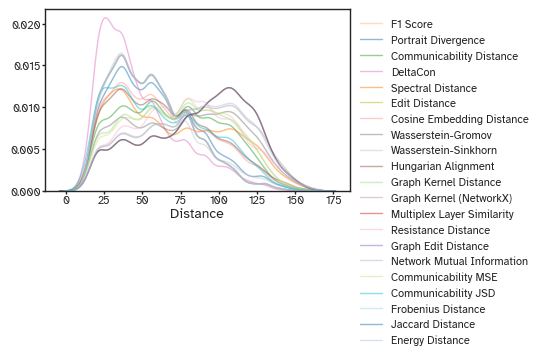

In [58]:
# plot degree distributions (smoothed) 
fig, ax = plt.subplots(figsize=viz.cm_to_inch((10, 6)))
for mode, distances in distributions_distances.items():
    # Plot histogram with density=True for normalization
    sns.kdeplot(distances, 
                label=method_names[mode], # .replace('_', ' ').title(), 
                color=metric_colors[mode],
                ax=ax, 
                fill=False, # True, 
                alpha=0.5)
    # plt.legend(fontsize=8)
    plt.xlabel('Distance')
    plt.ylabel("") # 'Density')
    # Put the legend outside the plot, completely. 
    plt.legend(fontsize=8, 
               # loc='upper right', 
               bbox_to_anchor=(1, 1), frameon=False)
    
# get this colorbar 


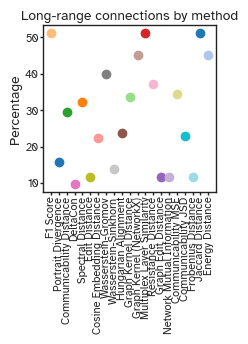

In [59]:
plt.figure(figsize=viz.cm_to_inch((6,9)))

for mode, distances in distributions_distances.items():
    # get percentage of distances above 90 
    percent_above_90 = np.sum(distances > 90) / len(distances) * 100
    plt.scatter(method_names[mode], percent_above_90, color=metric_colors[mode])
plt.xticks(rotation=90)
plt.ylabel('Percentage')
plt.title('Long-range connections by method')
plt.tight_layout()
plt.show()

# Degeneration

In [60]:
from typing import Dict, List

# Base directory for your chaos analysis results
base_dir = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis"
output_dir = f"{base_dir}/plots"
Path(output_dir).mkdir(parents=True, exist_ok=True)


degeneration_x_label_descriptor = "Degeneration Level\n(Consensus to Chaos)" # 'Step (0=Consensus -> Max=Chaos)'


Plotting individual metrics...
Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_f1.png


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


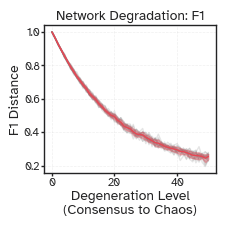

Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_portrait.png


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


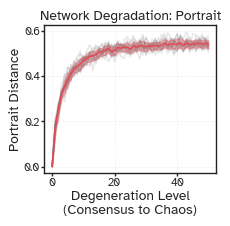

Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_communicability.png


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


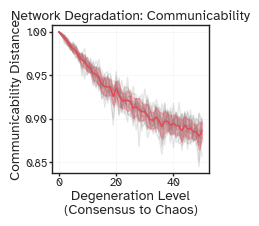

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_delta_con.png


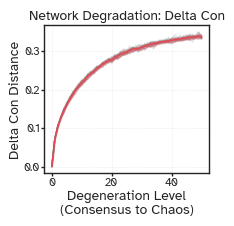

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_spectral_distance.png


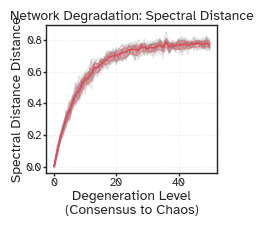

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_edit_distance.png


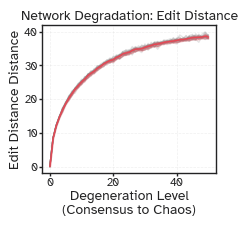

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_cosine_embedding.png


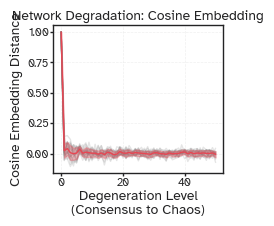

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_wasserstein_gromov.png


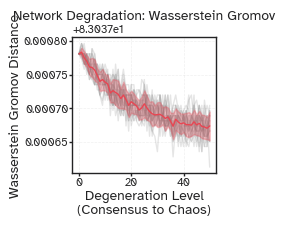

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_wasserstein_sinkhorn.png


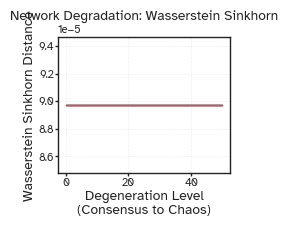

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_hungarian_alignment.png


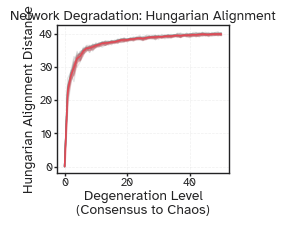

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_graph_kernel.png


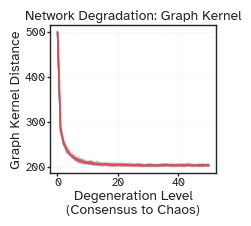

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_graph_kernel_networkx.png


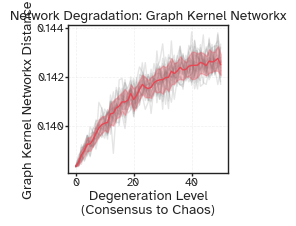

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_multiplex_layer_similarity.png


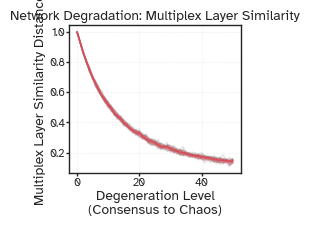

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_resistance_distance.png


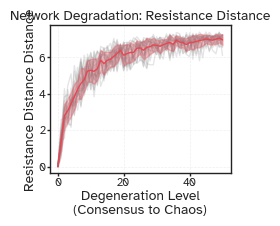

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_graph_edit_distance.png


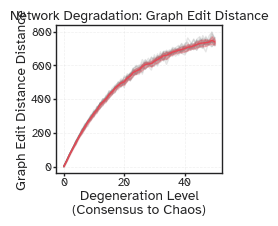

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_network_mutual_information.png


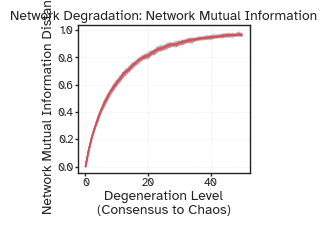

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_communicability_mse.png


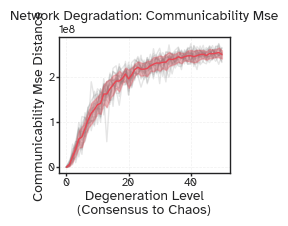

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_communicability_jsd.png


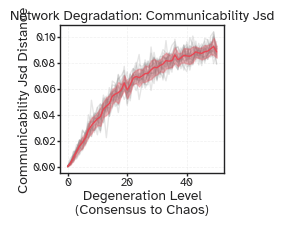

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_frobenius.png


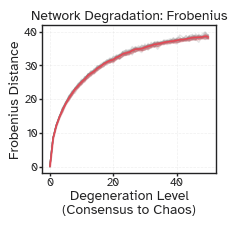

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_jaccard.png


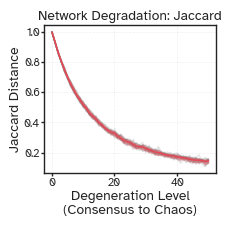

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_64366/2935767276.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='best')


Saved plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_energy.png


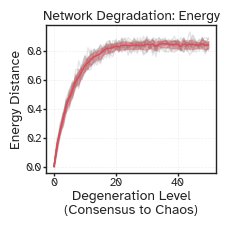

In [61]:

def plot_single_metric_chaos(
    csv_path: str,
    output_path: str = None,
    figsize_cm: tuple = (18, 12),
    show_individual_processes: bool = True,
    show_mean: bool = True,
    show_std_band: bool = True,
    alpha_individual: float = 0.2,
    title: str = None
):
    """
    Plot how a single metric changes from consensus to chaos.
    """
    # Load data
    df = pd.read_csv(csv_path)
    
    # Extract metric name from filename
    csv_filename = Path(csv_path).stem
    metric_name = csv_filename.replace('chaos_analysis_', '').replace('_', ' ').title()
    
    # Create figure
    fig, ax = plt.subplots(figsize=viz.cm_to_inch(figsize_cm))
    
    # Get unique process IDs
    process_ids = sorted(df['process_id'].unique())
    
    # Plot individual processes
    if show_individual_processes:
        for process_id in process_ids:
            df_process = df[df['process_id'] == process_id].sort_values('step')
            ax.plot(
                df_process['step'],
                df_process['metric_value'],
                alpha=alpha_individual,
                color='gray',
                linewidth=1,
                zorder=1
            )
    
    # Calculate mean and std across processes for each step
    df_summary = df.groupby('step')['metric_value'].agg(['mean', 'std']).reset_index()
    
    # Plot mean trajectory
    if show_mean:
        ax.plot(
            df_summary['step'],
            df_summary['mean'],
            color=lecker_red,
            # linewidth=2.5,
            # label='Mean trajectory',
            zorder=3
        )
    
    # Plot standard deviation band
    if show_std_band:
        ax.fill_between(
            df_summary['step'],
            df_summary['mean'] - df_summary['std'],
            df_summary['mean'] + df_summary['std'],
            alpha=0.3,
            color=lecker_red,
            # label='±1 SD',
            zorder=2
        )
    
    # Formatting
    ax.set_xlabel(degeneration_x_label_descriptor) # , fontsize=11)
    ax.set_ylabel(f'{metric_name} Distance') # , fontsize=11)
    
    if title:
        ax.set_title(title) # , fontsize=12, fontweight='bold')
    else:
        ax.set_title(f'Network Degradation: {metric_name}') # , fontsize=12, fontweight='bold')
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Add legend if showing mean/std
    if show_mean or show_std_band:
        ax.legend(frameon=False, loc='best')
    
    # Tight layout
    plt.tight_layout()
    
    # Save or show
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Saved plot to: {output_path}")
    else:
        plt.show()
    
    # plt.close()
    plt.show()
    
    return fig, ax



# Plot individual metrics
print("Plotting individual metrics...")
for metric in all_methods:
    csv_path = f"{base_dir}/chaos_analysis_{metric}.csv"
    if Path(csv_path).exists():
        output_path = f"{output_dir}/chaos_{metric}.png"
        plot_single_metric_chaos(
            csv_path=csv_path,
            output_path=output_path,
            figsize_cm=(6,6), 
            show_individual_processes=True,
            show_mean=True,
            show_std_band=True
        )
    else:
        print(f"Warning: {csv_path} not found, skipping...")



Plotting comparison...
Saved comparison plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_comparison_all_metrics.png


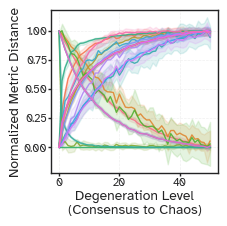

In [62]:
def plot_multiple_metrics_comparison(
    csv_paths: Dict[str, str],
    output_path: str = None,
    figsize_cm: tuple = (20, 12),
    normalize: bool = True,
    colors: List[str] = None
):
    """
    Compare multiple metrics on the same plot.
    """
    fig, ax = plt.subplots(figsize=viz.cm_to_inch(figsize_cm))
    
    if colors is None:
        colors = sns.color_palette("husl", len(csv_paths))
    
    for idx, (metric_name, csv_path) in enumerate(csv_paths.items()):
        # Load data
        df = pd.read_csv(csv_path)
        
        # Calculate mean trajectory
        df_summary = df.groupby('step')['metric_value'].agg(['mean', 'std']).reset_index()
        
        # Normalize if requested
        if normalize:
            min_val = df_summary['mean'].min()
            max_val = df_summary['mean'].max()
            if max_val > min_val:  # Avoid division by zero
                df_summary['mean_norm'] = (df_summary['mean'] - min_val) / (max_val - min_val)
                df_summary['std_norm'] = df_summary['std'] / (max_val - min_val)
                y_col = 'mean_norm'
                std_col = 'std_norm'
            else:
                y_col = 'mean'
                std_col = 'std'
        else:
            y_col = 'mean'
            std_col = 'std'
        
        # Plot
        color = colors[idx]
        ax.plot(
            df_summary['step'],
            df_summary[y_col],
            color=color,
            # linewidth=2,
            label=method_names[metric_name], # tric_name.replace('_', ' ').title(),
            alpha=0.9
        )
        
        # Optional: add std band
        ax.fill_between(
            df_summary['step'],
            df_summary[y_col] - df_summary[std_col],
            df_summary[y_col] + df_summary[std_col],
            alpha=0.15,
            color=color
        )
    
    # Formatting
    ax.set_xlabel(degeneration_x_label_descriptor)
    if normalize:
        ax.set_ylabel('Normalized Metric Distance') # , fontsize=11)
    else:
        ax.set_ylabel('Metric Distance')

    # ax.set_title('Comparison of Metrics During Network Degradation', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    # ax.legend(frameon=False, loc='best', bbox_to_anchor=(1.05, 1))
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Saved comparison plot to: {output_path}")
    else:
        plt.show()
    
    # plt.close()
    plt.show()
    
    return fig, ax


# Plot comparison of all metrics
print("\nPlotting comparison...")
csv_paths = {}
for metric in all_methods:
    csv_path = f"{base_dir}/chaos_analysis_{metric}.csv"
    if Path(csv_path).exists():
        csv_paths[metric] = csv_path

if csv_paths:
    plot_multiple_metrics_comparison(
        csv_paths=csv_paths,
        output_path=f"{output_dir}/chaos_comparison_all_metrics.png",
        figsize_cm=(6,6),
        normalize=True
    )




Creating heatmaps...
Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_f1.png


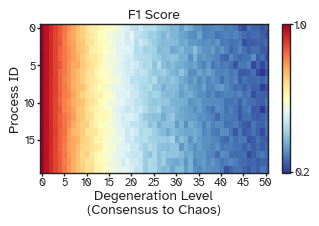

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_portrait.png


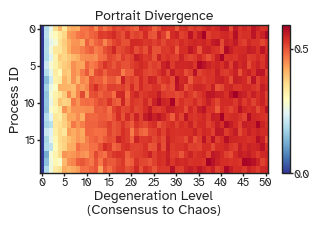

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_communicability.png


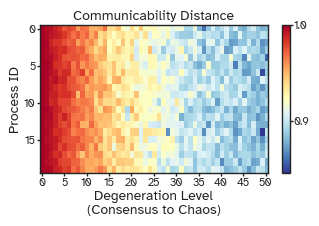

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_delta_con.png


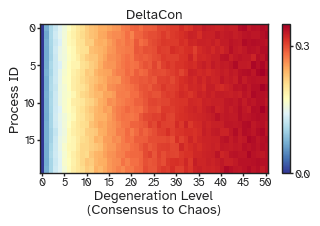

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_spectral_distance.png


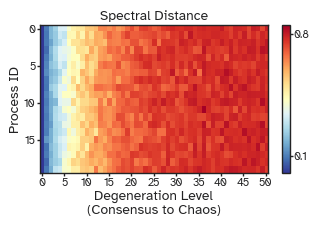

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_edit_distance.png


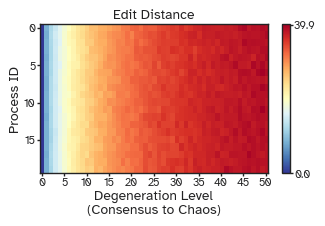

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_cosine_embedding.png


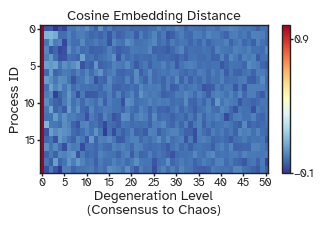

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_wasserstein_gromov.png


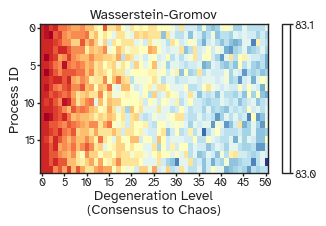

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_wasserstein_sinkhorn.png


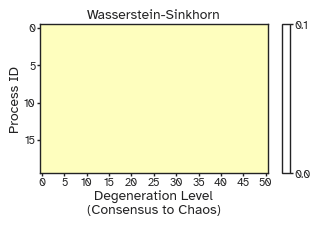

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_hungarian_alignment.png


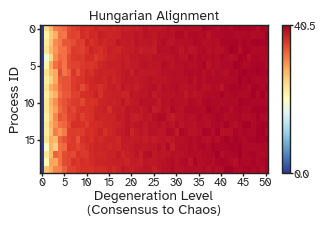

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_graph_kernel.png


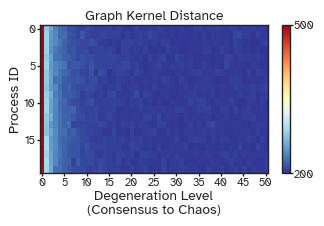

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_graph_kernel_networkx.png


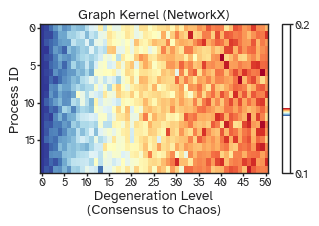

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_multiplex_layer_similarity.png


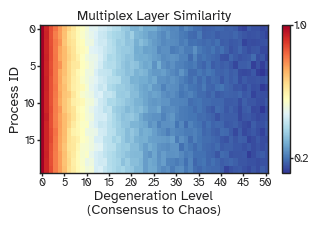

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_resistance_distance.png


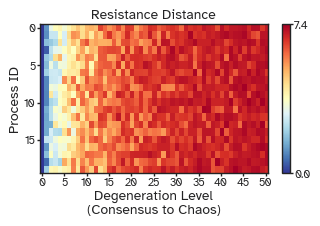

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_graph_edit_distance.png


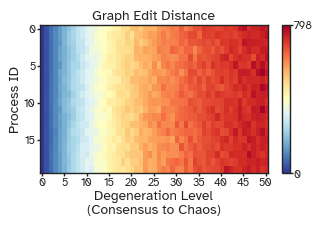

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_network_mutual_information.png


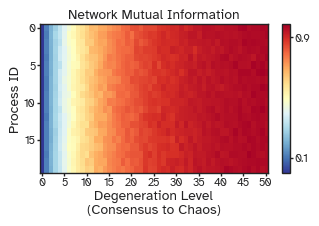

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_communicability_mse.png


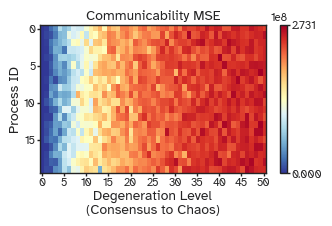

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_communicability_jsd.png


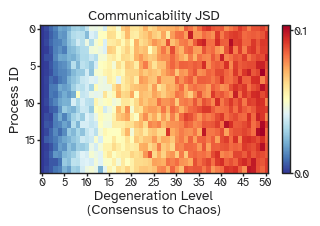

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_frobenius.png


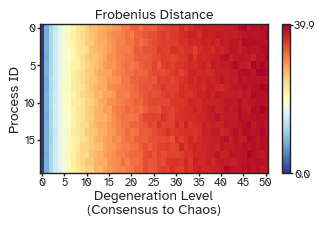

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_jaccard.png


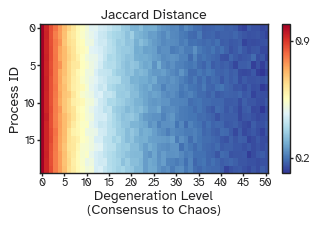

Saved heatmap to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_heatmap_energy.png


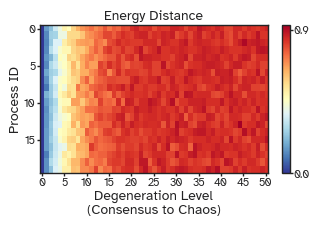

In [63]:

def plot_metric_heatmap(
    metric,
    csv_path: str,
    output_path: str = None,
    figsize_cm: tuple = (20, 12),
    cmap: str = 'viridis'
):
    """
    Create a heatmap showing metric values for all processes across all steps.
    """
    # Load data
    df = pd.read_csv(csv_path)
    
    # Pivot to create matrix: rows=process_id, columns=step
    pivot_data = df.pivot(index='process_id', columns='step', values='metric_value')
    
    # Create figure
    fig, ax = plt.subplots(figsize=viz.cm_to_inch(figsize_cm))
    
    # Create heatmap
    im = ax.imshow(pivot_data.values, aspect='auto', cmap=cmap, interpolation='nearest')
    
    # Set ticks
    ax.set_xticks(np.arange(0, len(pivot_data.columns), max(1, len(pivot_data.columns) // 10)))
    ax.set_xticklabels(pivot_data.columns[::max(1, len(pivot_data.columns) // 10)])
    # ax.set_yticks(np.arange(len(pivot_data.index)))
    # ax.set_yticklabels(pivot_data.index)
    
    # Labels
    ax.set_xlabel(degeneration_x_label_descriptor) # 'Network Degradation\n(Consensus → Chaos)')
    ax.set_ylabel('Process ID')

    # Extract metric name
    metric_name = method_names[metric]  # Path(csv_path).stem.replace('chaos_analysis_', '').replace('_', ' ').title()
    ax.set_title(f'{metric_name}') # , fontsize=12, fontweight='bold')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    # get highest and lowest value of the colorbar ticks
    cbar.get_ticks()
    # and only set those
    # cbar.set_ticks([(cbar.get_ticks().min().ceil())/10, (10*cbar.get_ticks().max()).floor()/10])
    cbar.set_ticks([np.ceil(pivot_data.values.min()*10)/10, np.floor(pivot_data.values.max()*10)/10])

    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Saved heatmap to: {output_path}")
    else:
        plt.show()
    
    # plt.close()
    plt.show() 
    
    return fig, ax



# Optional: Create heatmaps for selected metrics
print("\nCreating heatmaps...")
for metric in all_methods: # ["energy", "portrait", "f1"]:  # Create heatmaps for key metrics
    csv_path = f"{base_dir}/chaos_analysis_{metric}.csv"
    if Path(csv_path).exists():
        output_path = f"{output_dir}/chaos_heatmap_{metric}.png"
        plot_metric_heatmap(
            metric,
            csv_path=csv_path,
            output_path=output_path,
            figsize_cm=(9,6),
            cmap='RdYlBu_r'
        )


# Old

In [64]:
def plot_clustered_correlation_heatmap(corr_matrix, save_path):
    """Plot and save clustered correlation matrix heatmap."""
    # Cluster the correlation matrix
    clustered_corr, order, linkage_matrix = cluster_correlation_matrix(corr_matrix)
    
    # Create figure with dendrogram
    fig = plt.figure(figsize=(16, 14))
    
    # Add dendrogram
    ax_dendro = fig.add_axes([0.05, 0.71, 0.15, 0.2])
    dendro = dendrogram(linkage_matrix, orientation='left', ax=ax_dendro)
    ax_dendro.set_xticks([])
    ax_dendro.set_yticks([])
    ax_dendro.spines['top'].set_visible(False)
    ax_dendro.spines['right'].set_visible(False)
    ax_dendro.spines['bottom'].set_visible(False)
    ax_dendro.spines['left'].set_visible(False)
    
    # Add heatmap
    ax_heatmap = fig.add_axes([0.22, 0.1, 0.7, 0.8])
    sns.heatmap(clustered_corr, annot=True, fmt='.2f', cmap='RdBu_r', 
                center=0, vmin=-1, vmax=1, square=True,
                cbar_kws={'label': 'Pearson Correlation'},
                ax=ax_heatmap, linewidths=0.5)
    
    ax_heatmap.set_title('Clustered Correlation Matrix: Methods vs Approximated Ground Truth', 
                         fontsize=16, pad=20)
    ax_heatmap.set_xticklabels(ax_heatmap.get_xticklabels(), rotation=45, ha='right')
    ax_heatmap.set_yticklabels(ax_heatmap.get_yticklabels(), rotation=0)
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved clustered correlation heatmap to {save_path}")
    
    return clustered_corr



In [65]:

def plot_clustered_correlation_heatmap(corr_matrix, save_path):
    """Plot and save clustered correlation matrix heatmap."""
    # Cluster the correlation matrix
    clustered_corr, order, linkage_matrix = cluster_correlation_matrix(corr_matrix)
    
    # Create figure with dendrogram
    fig = plt.figure(figsize=(16, 14))
    
    # Add dendrogram
    ax_dendro = fig.add_axes([0.05, 0.71, 0.15, 0.2])
    dendro = dendrogram(linkage_matrix, orientation='left', ax=ax_dendro)
    ax_dendro.set_xticks([])
    ax_dendro.set_yticks([])
    ax_dendro.spines['top'].set_visible(False)
    ax_dendro.spines['right'].set_visible(False)
    ax_dendro.spines['bottom'].set_visible(False)
    ax_dendro.spines['left'].set_visible(False)
    
    # Add heatmap
    ax_heatmap = fig.add_axes([0.22, 0.1, 0.7, 0.8])
    sns.heatmap(clustered_corr, annot=True, fmt='.2f', cmap='RdBu_r', 
                center=0, vmin=-1, vmax=1, square=True,
                cbar_kws={'label': 'Pearson Correlation'},
                ax=ax_heatmap, linewidths=0.5)
    
    ax_heatmap.set_title('Clustered Correlation Matrix: Methods vs Approximated Ground Truth', 
                         fontsize=16, pad=20)
    ax_heatmap.set_xticklabels(ax_heatmap.get_xticklabels(), rotation=45, ha='right')
    ax_heatmap.set_yticklabels(ax_heatmap.get_yticklabels(), rotation=0)
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved clustered correlation heatmap to {save_path}")
    
    return clustered_corr

def plot_correlation_network(corr_matrix, save_path, threshold=0.5):
    """
    Create a network graph where methods are nodes and correlations are edges.
    
    Parameters:
    -----------
    corr_matrix : pd.DataFrame
        Correlation matrix
    save_path : Path
        Path to save the figure
    threshold : float
        Minimum absolute correlation value to draw an edge (default: 0.5)
    """
    # Create graph
    G = nx.Graph()
    
    # Add nodes
    methods = corr_matrix.columns.tolist()
    G.add_nodes_from(methods)
    
    # Add edges for correlations above threshold
    for i, method1 in enumerate(methods):
        for j, method2 in enumerate(methods):
            if i < j:  # Avoid duplicate edges
                corr_value = corr_matrix.loc[method1, method2]
                if not np.isnan(corr_value) and abs(corr_value) >= threshold:
                    G.add_edge(method1, method2, weight=abs(corr_value), 
                              correlation=corr_value)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 16))
    
    # Use spring layout (Fruchterman-Reingold)
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    
    # Draw nodes
    node_colors = []
    for node in G.nodes():
        if node == 'approximated_ground_truth':
            node_colors.append('#ef4444')  # Red for ground truth
        else:
            node_colors.append('#6366f1')  # Blue for methods
    
    node_sizes = [3000 if node == 'approximated_ground_truth' else 2000 
                  for node in G.nodes()]
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                          node_size=node_sizes, alpha=0.9, ax=ax)
    
    # Draw edges with varying thickness and color based on correlation
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    correlations = [G[u][v]['correlation'] for u, v in edges]
    
    # Normalize edge widths
    edge_widths = [w * 5 for w in weights]
    
    # Color edges by positive/negative correlation
    edge_colors = ['#22c55e' if c > 0 else '#ef4444' for c in correlations]
    
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6,
                          edge_color=edge_colors, ax=ax)
    
    # Draw labels
    labels = {node: node.replace('_', '\n') for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=8, 
                           font_weight='bold', ax=ax)
    
    # Add title and legend
    ax.set_title(f'Method Correlation Network (|r| ≥ {threshold})', 
                fontsize=18, fontweight='bold', pad=20)
    ax.axis('off')
    
    # Create custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#ef4444', 
               markersize=15, label='Ground Truth'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#6366f1', 
               markersize=12, label='Methods'),
        Line2D([0], [0], color='#22c55e', linewidth=3, label='Positive Correlation'),
        Line2D([0], [0], color='#ef4444', linewidth=3, label='Negative Correlation'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved correlation network to {save_path}")
    
    # Print network statistics
    print(f"\nNetwork Statistics:")
    print(f"  Number of nodes: {G.number_of_nodes()}")
    print(f"  Number of edges: {G.number_of_edges()}")
    if G.number_of_nodes() > 0:
        print(f"  Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
    
    return G


GROUND TRUTH ANALYSIS
Normalization: zscore
Use KS Statistic: False

Loading method data...
  ✓ Loaded portrait: 2500 rows
  ✓ Loaded energy: 2500 rows
  ✓ Loaded spectral_distance: 2500 rows
  ✓ Loaded f1: 2500 rows
  ✓ Loaded communicability: 2500 rows
  ✓ Loaded graph_kernel: 2500 rows
  ✓ Loaded multiplex_layer_similarity: 2500 rows
  ✓ Loaded cosine_embedding: 2500 rows
  ✓ Loaded graph_edit_distance: 2500 rows
  ✓ Loaded network_mutual_information: 2500 rows
  ✓ Loaded hungarian_alignment: 2500 rows
  ✓ Loaded graph_kernel_networkx: 2500 rows
  ✓ Loaded delta_con: 2500 rows
  ✓ Loaded resistance_distance: 2500 rows
  ✓ Loaded wasserstein_gromov: 2500 rows
  ✓ Loaded wasserstein_sinkhorn: 2500 rows

Combined data: 40000 total rows

Calculating approximated ground truth (normalization: zscore)...
  Ground truth calculated for 2500 unique eta-gamma-id combinations

Creating full dataset with all methods...
  Full dataset shape: (2500, 20)

DESCRIPTIVE STATISTICS

portrait:
  Count: 

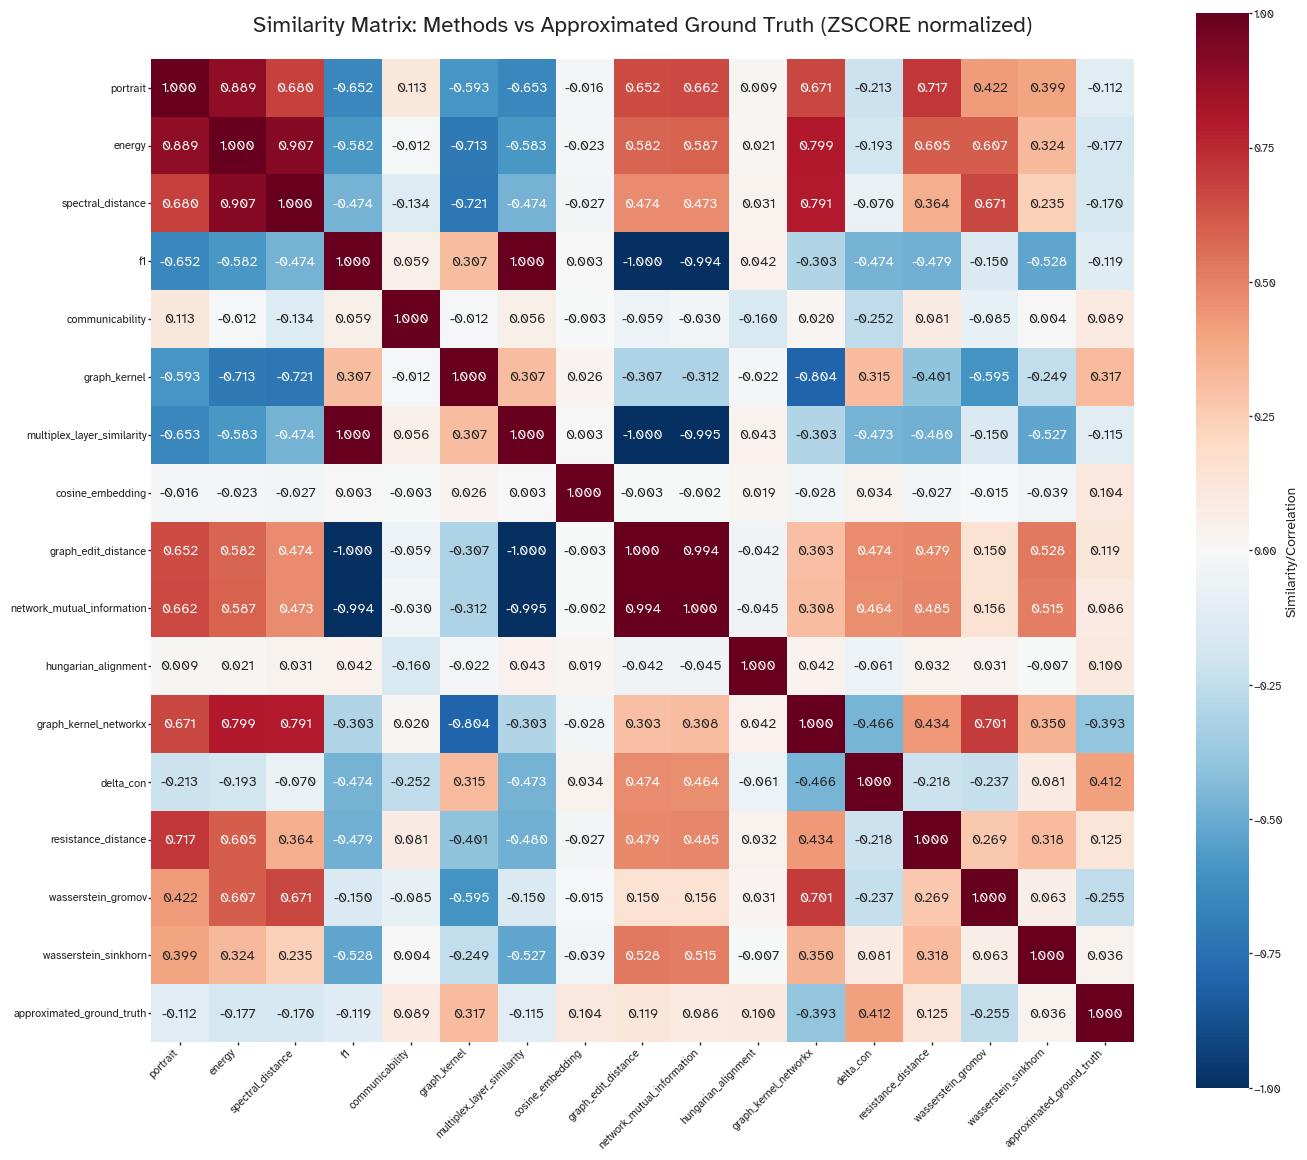

Saved heatmap to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/01_ring_sweep_animal_0/ground_truth_analysis/correlation_matrix_heatmap_zscore.png


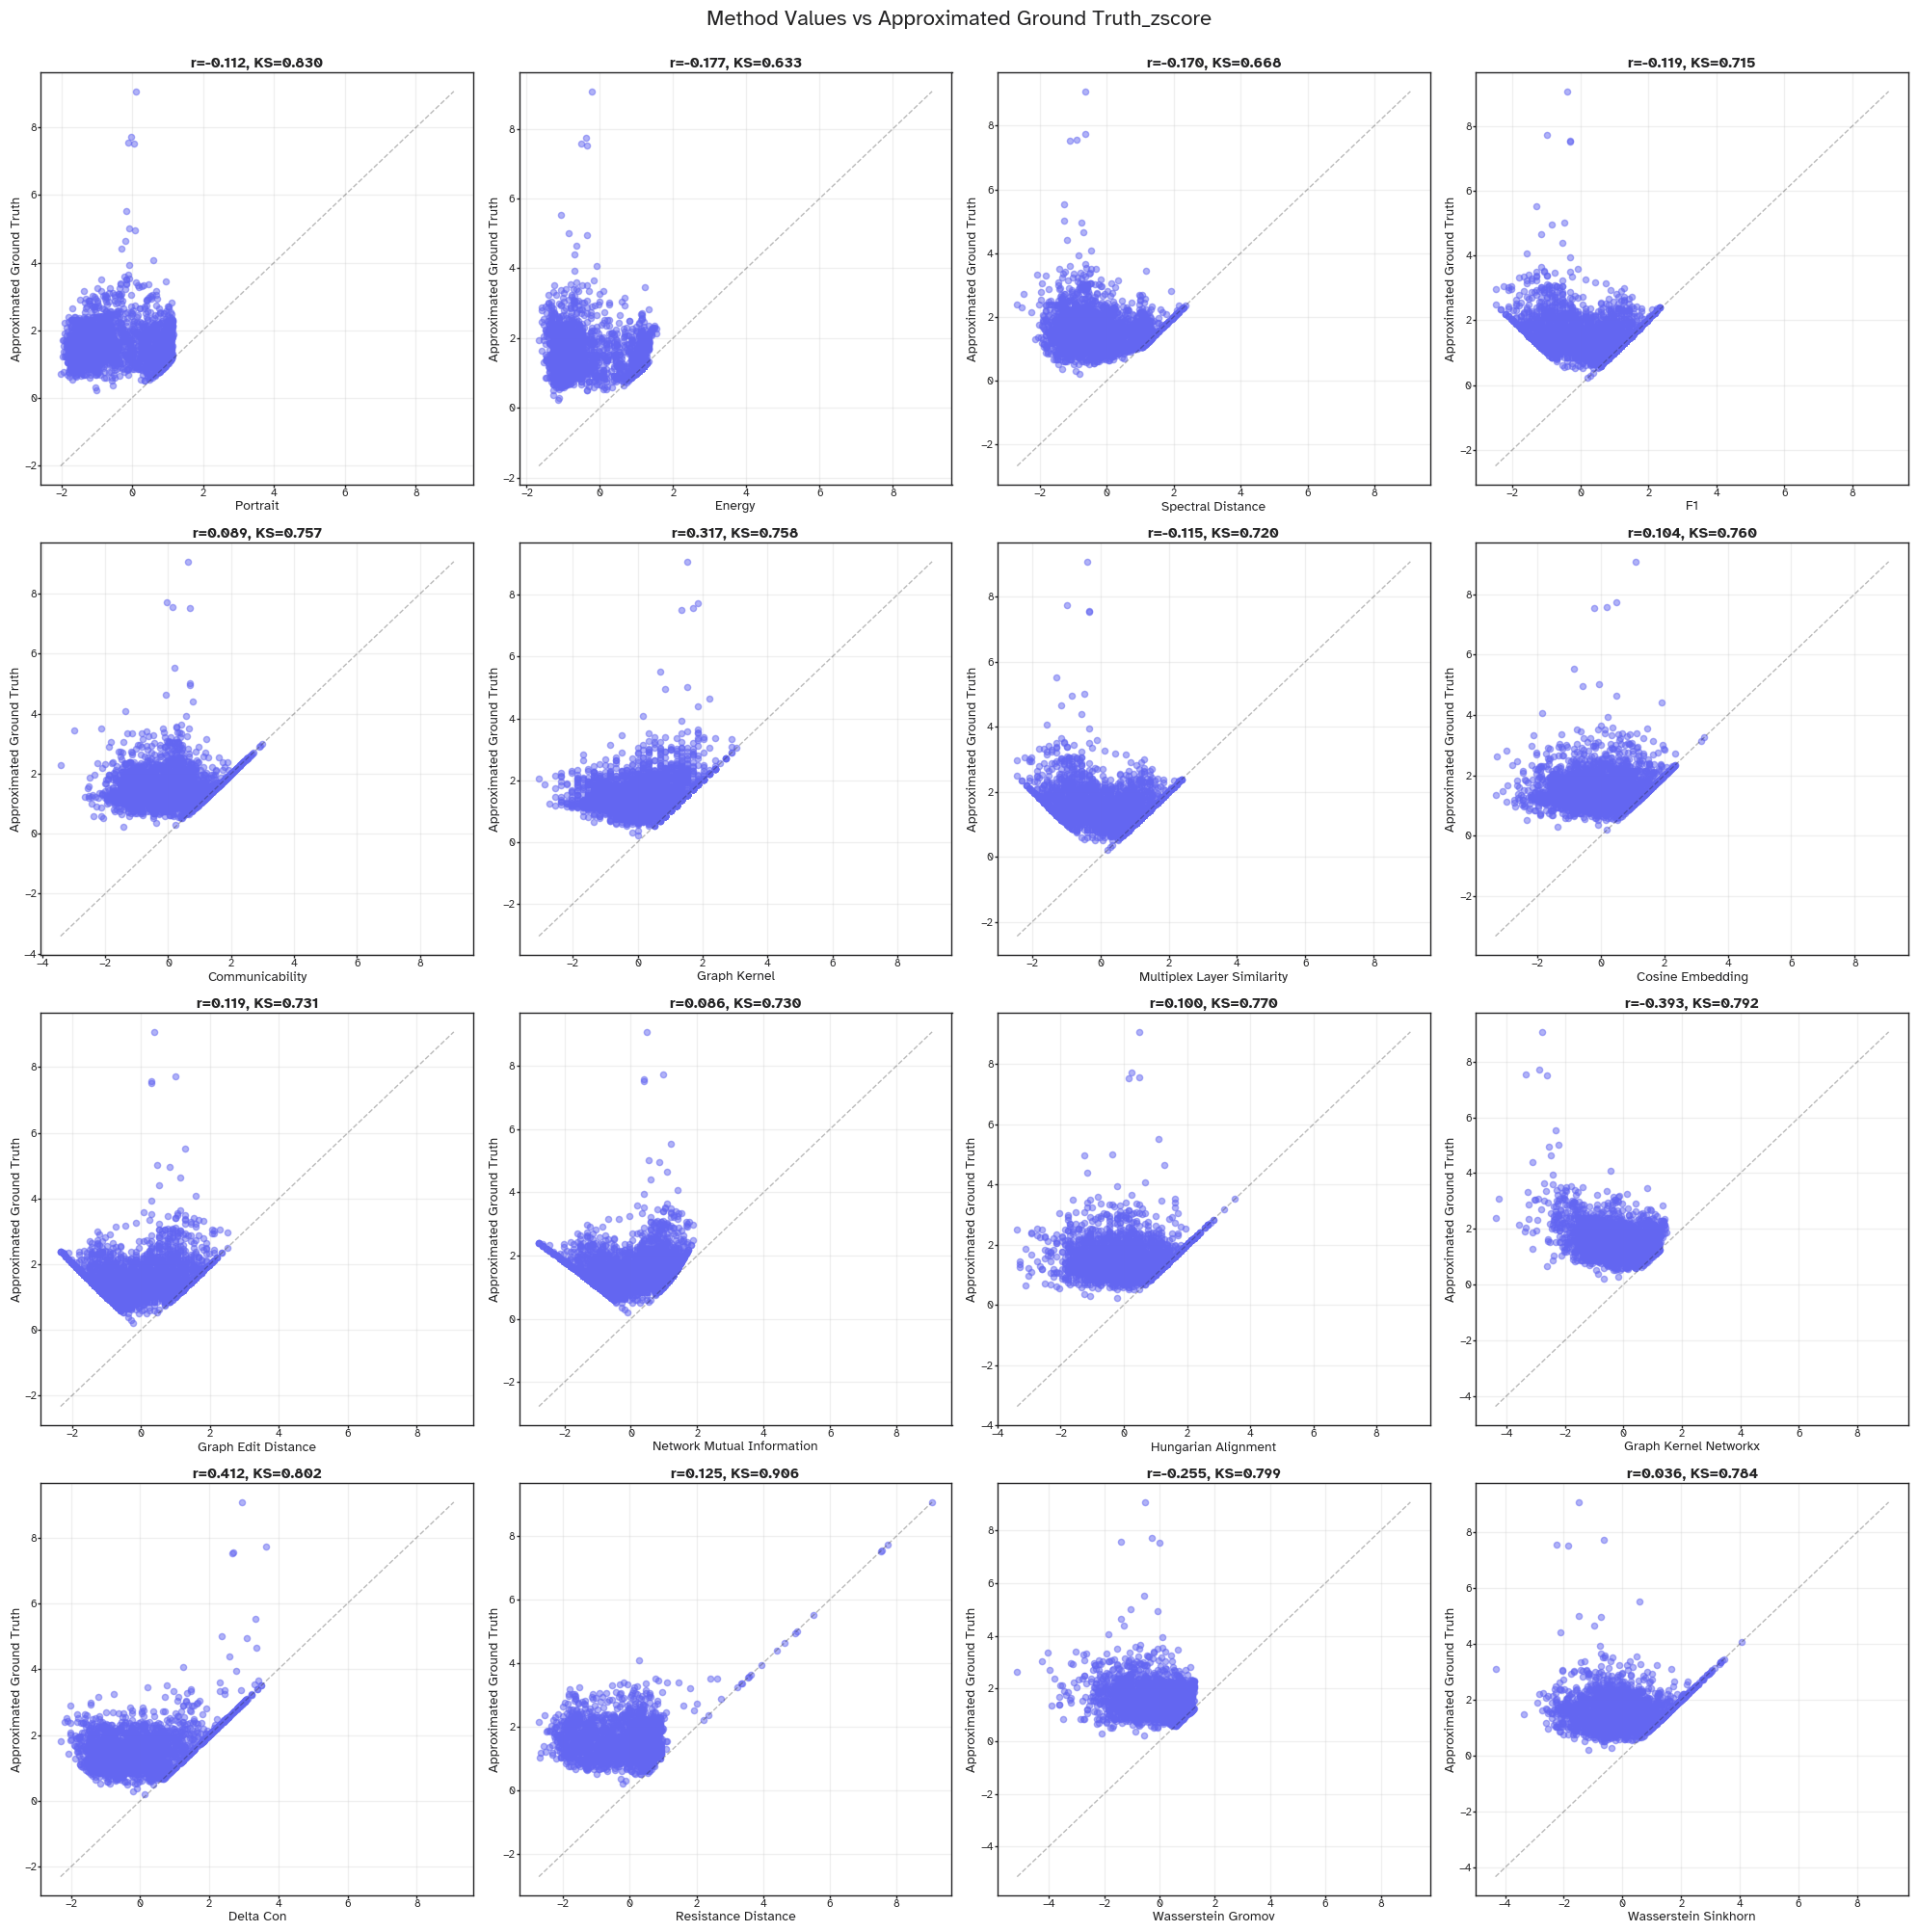

Saved scatter plots to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/01_ring_sweep_animal_0/ground_truth_analysis/scatter_plots_all_methods_zscore.png


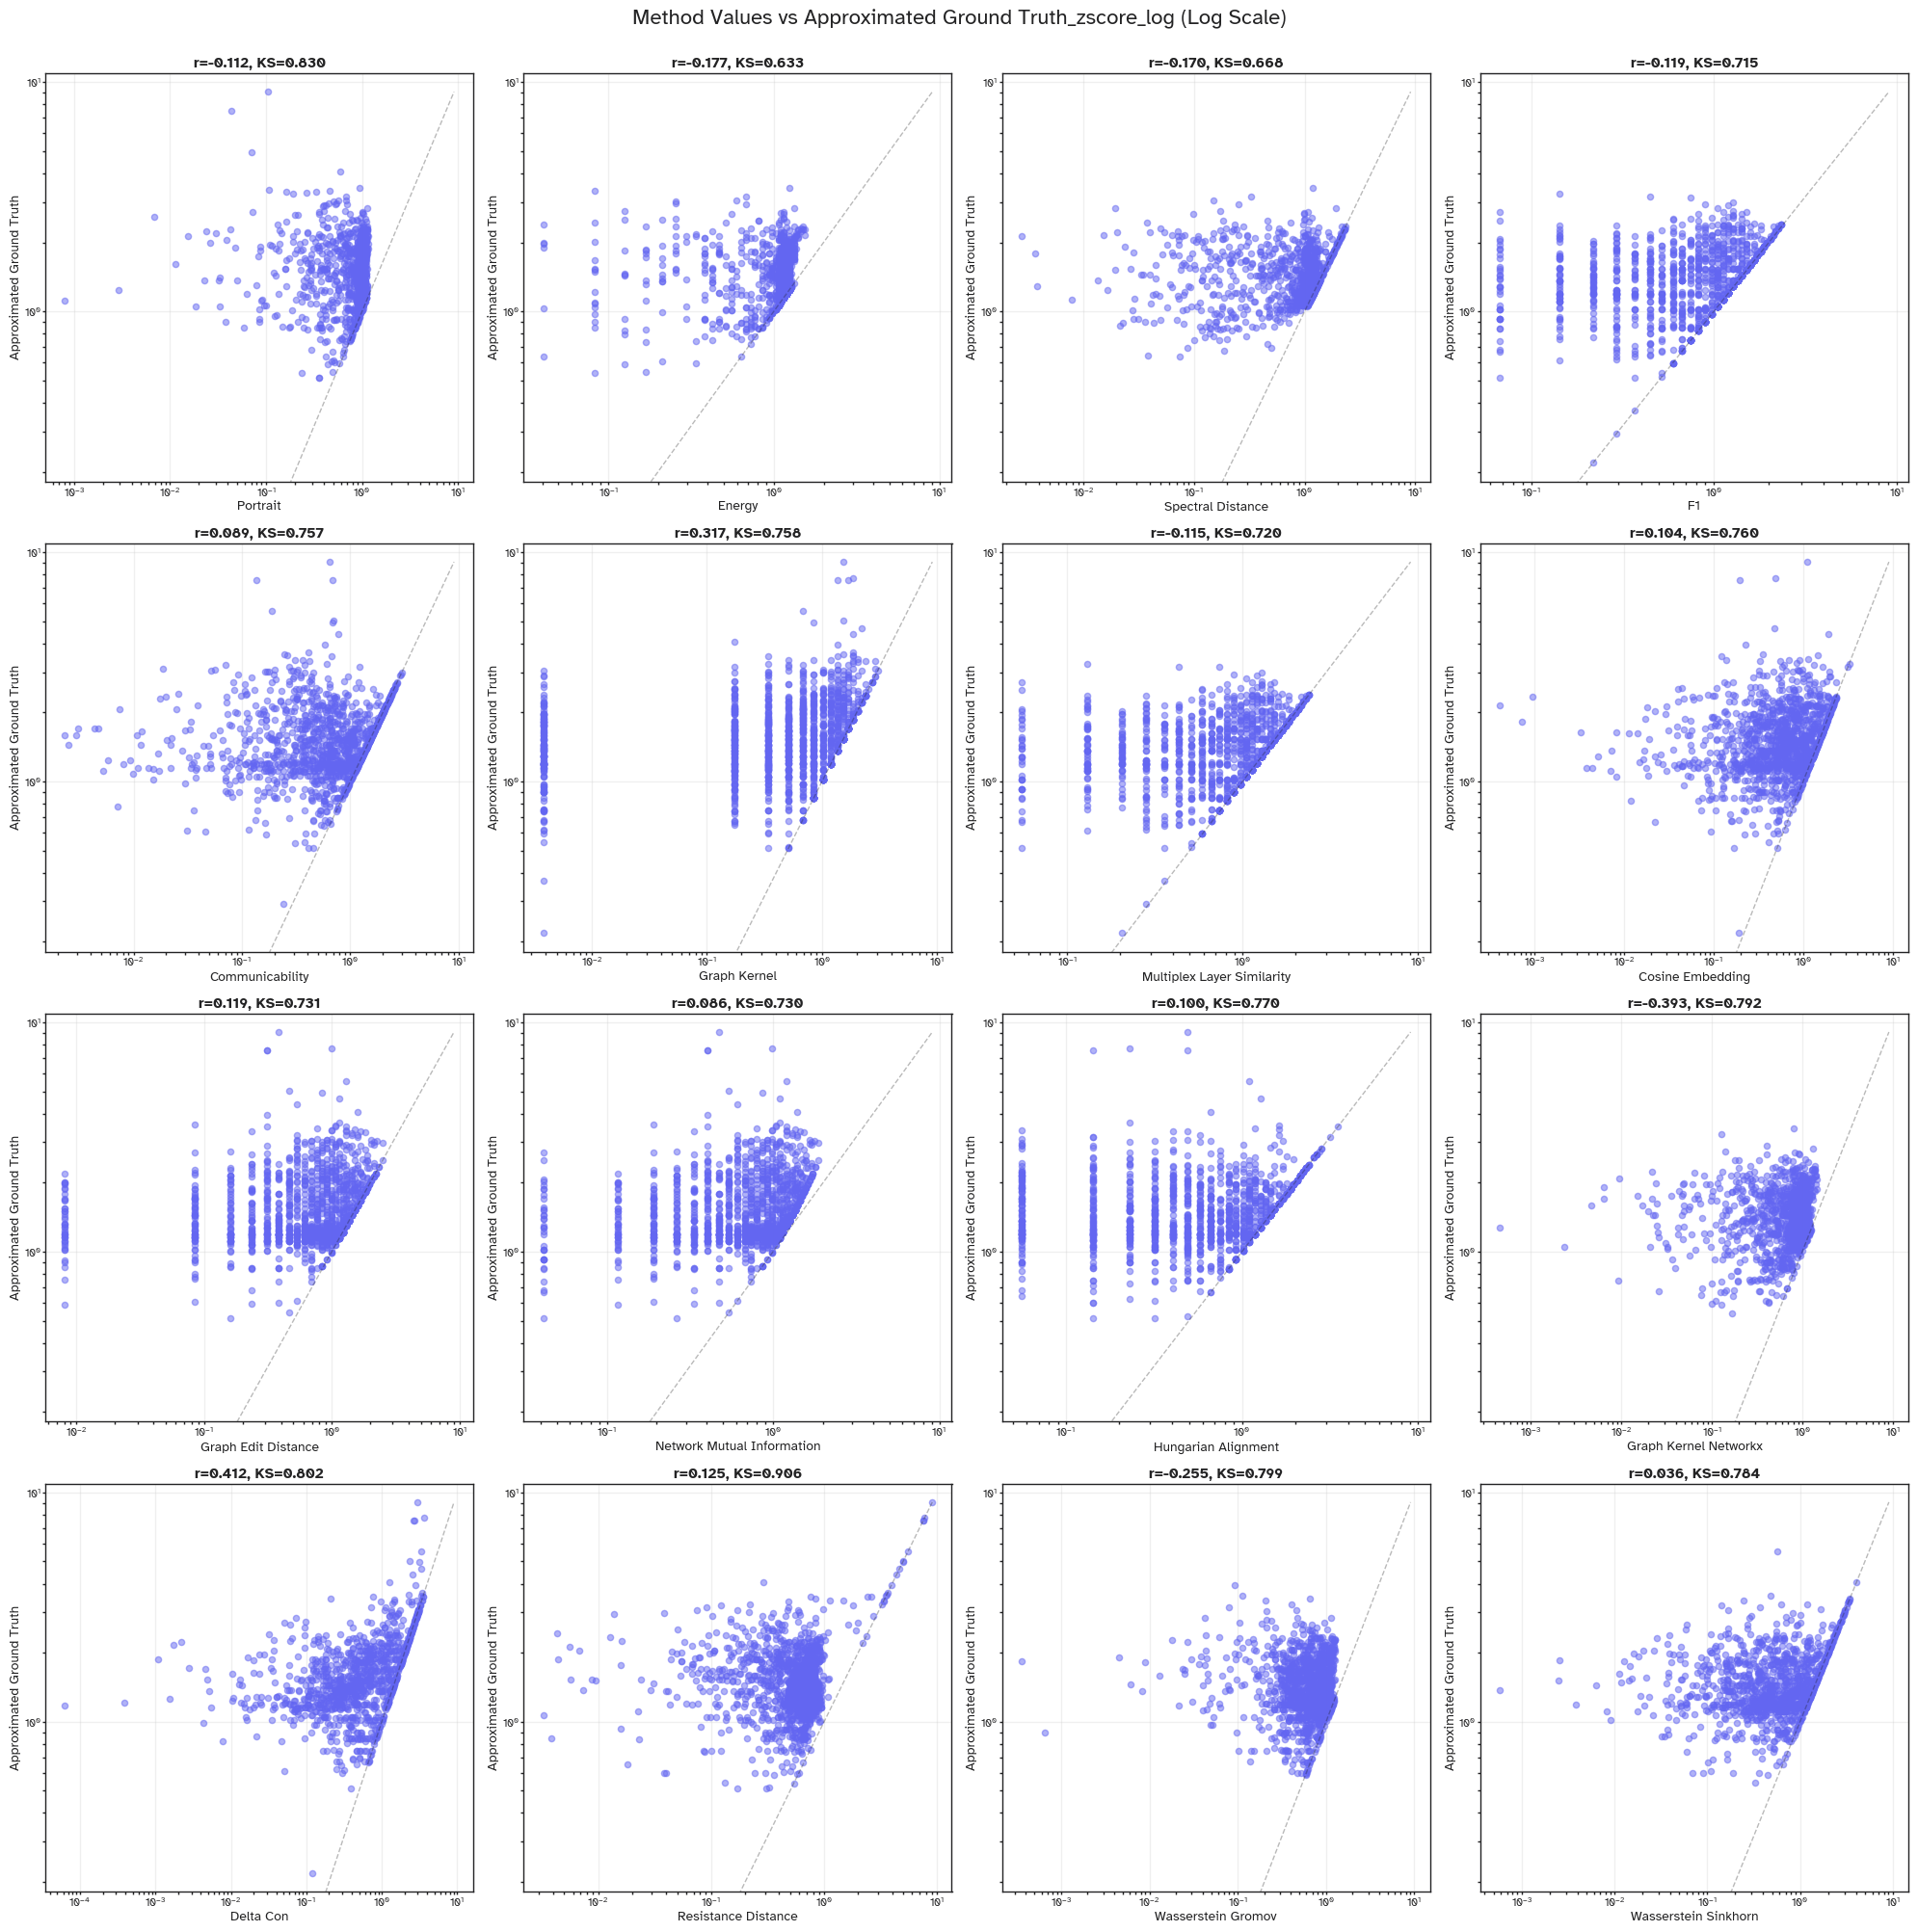

Saved scatter plots to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/01_ring_sweep_animal_0/ground_truth_analysis/scatter_plots_all_methods_zscore_log.png

Analysis complete!
All outputs saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/01_ring_sweep_animal_0/ground_truth_analysis


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# Configuration
output_path = Path(base_path) / "ground_truth_analysis"
output_path.mkdir(exist_ok=True)

all_methods = [
    "portrait", "energy", "spectral_distance", "f1", "communicability",
    "graph_kernel", "multiplex_layer_similarity", "cosine_embedding",
    "graph_edit_distance", "network_mutual_information", "hungarian_alignment",
    "graph_kernel_networkx", "delta_con", "resistance_distance",
    "wasserstein_gromov", "wasserstein_sinkhorn"
]

# Analysis options
NORMALIZATION = "zscore" # minmax"  # Options: None, "minmax", "zscore", "rank"
USE_KS_STATISTIC = False # True #  False  # If True, use KS statistic instead of correlation

def load_method_data(method):
    """Load data for a specific method."""
    path = f"{base_path}/summary_indiv_{method}_for_exp_{experiment_name}.csv"
    try:
        df = pd.read_csv(path)
        # Find metric column (not eta, gamma, network_index, filename, id)
        metric_cols = [col for col in df.columns 
                      if col not in ["eta", "gamma", "network_index", "filename", "id"]]
        if metric_cols:
            df['metric_value'] = df[metric_cols[0]]
            df['method'] = method
            return df[['eta', 'gamma', 'id', 'metric_value', 'method']]
        return None
    except FileNotFoundError:
        print(f"Warning: File not found for method {method}")
        return None

def normalize_data(df, method='minmax'):
    """Normalize data using different methods."""
    if method == 'minmax':
        # Min-max normalization to [0, 1]
        min_val = df.min()
        max_val = df.max()
        return (df - min_val) / (max_val - min_val) if max_val > min_val else df
    elif method == 'zscore':
        # Z-score normalization
        return (df - df.mean()) / df.std() if df.std() > 0 else df
    elif method == 'rank':
        # Rank-based normalization
        return df.rank(pct=True)
    else:
        return df

def calculate_ground_truth(all_data, normalization=None):
    """Calculate approximated ground truth as max across methods for each eta-gamma-id."""
    if normalization:
        # Normalize within each method first
        normalized_list = []
        for method in all_data['method'].unique():
            method_data = all_data[all_data['method'] == method].copy()
            method_data['metric_value'] = normalize_data(method_data['metric_value'], normalization)
            normalized_list.append(method_data)
        all_data = pd.concat(normalized_list, ignore_index=True)
    
    # Group by eta, gamma, id and take maximum
    ground_truth = all_data.groupby(['eta', 'gamma', 'id'])['metric_value'].max().reset_index()
    ground_truth.rename(columns={'metric_value': 'approximated_ground_truth'}, inplace=True)
    return ground_truth, all_data

def create_full_dataset(all_data, ground_truth):
    """Create dataset with all methods and ground truth."""
    # Pivot to get methods as columns
    pivot_data = all_data.pivot_table(
        index=['eta', 'gamma', 'id'],
        columns='method',
        values='metric_value'
    ).reset_index()
    
    # Merge with ground truth
    full_data = pivot_data.merge(ground_truth, on=['eta', 'gamma', 'id'])
    return full_data

def calculate_ks_matrix(full_data, methods):
    """Calculate KS statistic matrix between methods and ground truth."""
    n = len(methods) + 1
    ks_matrix = pd.DataFrame(index=methods + ['approximated_ground_truth'],
                             columns=methods + ['approximated_ground_truth'])
    
    all_cols = methods + ['approximated_ground_truth']
    
    for i, col1 in enumerate(all_cols):
        for j, col2 in enumerate(all_cols):
            if i == j:
                ks_matrix.loc[col1, col2] = 1.0
            else:
                data1 = full_data[col1].dropna()
                data2 = full_data[col2].dropna()
                # Use common indices
                common_idx = data1.index.intersection(data2.index)
                if len(common_idx) > 0:
                    ks_stat, _ = stats.ks_2samp(data1.loc[common_idx], data2.loc[common_idx])
                    # Convert to similarity: 1 - KS statistic
                    ks_matrix.loc[col1, col2] = 1 - ks_stat
                else:
                    ks_matrix.loc[col1, col2] = np.nan
    
    return ks_matrix.astype(float)

def calculate_correlation_matrix(full_data, methods):
    """Calculate correlation matrix between methods and ground truth."""
    cols_to_correlate = methods + ['approximated_ground_truth']
    corr_matrix = full_data[cols_to_correlate].corr()
    return corr_matrix

def plot_correlation_heatmap(matrix, save_path, title_suffix=""):
    """Plot and save correlation/similarity matrix heatmap."""
    plt.figure(figsize=(14, 12))
    sns.heatmap(matrix, annot=True, fmt='.3f', cmap='RdBu_r', 
                center=0 if matrix.min().min() < 0 else 0.5,
                vmin=matrix.min().min(), vmax=1, square=True,
                cbar_kws={'label': 'Similarity/Correlation'})
    plt.title(f'Similarity Matrix: Methods vs Approximated Ground Truth{title_suffix}', 
              fontsize=16, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    # plt.close()
    plt.show()
    print(f"Saved heatmap to {save_path}")

def plot_scatter_plots(full_data, methods, save_dir, use_log=False, suffix=""):
    """Create scatter plots for each method vs ground truth."""
    n_methods = len(methods)
    n_cols = 4
    n_rows = int(np.ceil(n_methods / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = axes.flatten()
    
    for idx, method in enumerate(methods):
        ax = axes[idx]
        
        # Get data for this method
        x = full_data[method].dropna()
        y = full_data.loc[x.index, 'approximated_ground_truth']
        
        # Remove any remaining NaNs
        mask = ~(x.isna() | y.isna())
        x = x[mask]
        y = y[mask]
        
        if len(x) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            continue
        
        # Calculate correlation and KS statistic
        corr = x.corr(y)
        ks_stat, _ = stats.ks_2samp(x, y)
        
        # Scatter plot
        ax.scatter(x, y, alpha=0.5, s=20, color='#6366f1')
        
        # Add diagonal reference line
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], 
                'k--', alpha=0.3, linewidth=1)
        
        # Log scale if requested
        if use_log:
            ax.set_xscale('log')
            ax.set_yscale('log')
        
        # Labels and title
        ax.set_xlabel(method.replace('_', ' ').title(), fontsize=10)
        ax.set_ylabel('Approximated Ground Truth', fontsize=10)
        ax.set_title(f'r={corr:.3f}, KS={ks_stat:.3f}', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_methods, len(axes)):
        axes[idx].axis('off')
    
    scale_str = " (Log Scale)" if use_log else ""
    plt.suptitle(f'Method Values vs Approximated Ground Truth{suffix}{scale_str}', 
                 fontsize=16, y=1.00)
    plt.tight_layout()
    filename = f'scatter_plots_all_methods{suffix.replace(" ", "_").lower()}.png'
    save_path = save_dir / filename
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    # plt.close()
    plt.show()
    print(f"Saved scatter plots to {save_path}")

def print_statistics(full_data, methods):
    """Print descriptive statistics for all methods and ground truth."""
    print("\n" + "="*70)
    print("DESCRIPTIVE STATISTICS")
    print("="*70)
    
    cols = methods + ['approximated_ground_truth']
    for col in cols:
        data = full_data[col].dropna()
        if len(data) > 0:
            print(f"\n{col}:")
            print(f"  Count:   {len(data)}")
            print(f"  Mean:    {data.mean():.4f}")
            print(f"  Std:     {data.std():.4f}")
            print(f"  Min:     {data.min():.4f}")
            print(f"  25%:     {data.quantile(0.25):.4f}")
            print(f"  Median:  {data.median():.4f}")
            print(f"  75%:     {data.quantile(0.75):.4f}")
            print(f"  Max:     {data.max():.4f}")

def main():
    print("="*70)
    print("GROUND TRUTH ANALYSIS")
    print("="*70)
    print(f"Normalization: {NORMALIZATION if NORMALIZATION else 'None'}")
    print(f"Use KS Statistic: {USE_KS_STATISTIC}")
    print("="*70)
    
    print("\nLoading method data...")
    all_data_list = []
    loaded_methods = []
    
    for method in all_methods:
        df = load_method_data(method)
        if df is not None:
            all_data_list.append(df)
            loaded_methods.append(method)
            print(f"  ✓ Loaded {method}: {len(df)} rows")
    
    if not all_data_list:
        print("Error: No method data could be loaded!")
        return
    
    # Combine all method data
    all_data = pd.concat(all_data_list, ignore_index=True)
    print(f"\nCombined data: {len(all_data)} total rows")
    
    # Calculate ground truth with optional normalization
    print(f"\nCalculating approximated ground truth (normalization: {NORMALIZATION})...")
    ground_truth, normalized_data = calculate_ground_truth(all_data, NORMALIZATION)
    print(f"  Ground truth calculated for {len(ground_truth)} unique eta-gamma-id combinations")
    
    # Create full dataset
    print("\nCreating full dataset with all methods...")
    full_data = create_full_dataset(normalized_data, ground_truth)
    print(f"  Full dataset shape: {full_data.shape}")
    
    # Print statistics
    print_statistics(full_data, loaded_methods)
    
    # Save ground truth and full dataset
    suffix = f"_{NORMALIZATION}" if NORMALIZATION else ""
    
    gt_path = output_path / f'approximated_ground_truth{suffix}.csv'
    ground_truth.to_csv(gt_path, index=False)
    print(f"\n✓ Saved approximated ground truth to {gt_path}")
    
    full_path = output_path / f'full_dataset_with_ground_truth{suffix}.csv'
    full_data.to_csv(full_path, index=False)
    print(f"✓ Saved full dataset to {full_path}")
    
    # Calculate similarity matrix (KS or correlation)
    if USE_KS_STATISTIC:
        print("\nCalculating KS statistic similarity matrix...")
        similarity_matrix = calculate_ks_matrix(full_data, loaded_methods)
        matrix_name = "ks_similarity_matrix"
        print("\nKS-based Similarity with Approximated Ground Truth (1 - KS statistic):")
    else:
        print("\nCalculating correlation matrix...")
        similarity_matrix = calculate_correlation_matrix(full_data, loaded_methods)
        matrix_name = "correlation_matrix"
        print("\nCorrelations with Approximated Ground Truth:")
    
    # Save similarity matrix
    matrix_path = output_path / f'{matrix_name}{suffix}.csv'
    similarity_matrix.to_csv(matrix_path)
    print(f"✓ Saved {matrix_name} to {matrix_path}")
    
    # Display similarities with ground truth
    gt_sims = similarity_matrix['approximated_ground_truth'].drop('approximated_ground_truth').sort_values(ascending=False)
    for method, sim in gt_sims.items():
        print(f"  {method:30s}: {sim:6.3f}")
    
    # Create visualizations
    print("\nCreating visualizations...")
    
    # Similarity heatmap
    title_suffix = f" ({NORMALIZATION.upper()} normalized)" if NORMALIZATION else ""
    heatmap_path = output_path / f'{matrix_name}_heatmap{suffix}.png'
    plot_correlation_heatmap(similarity_matrix, heatmap_path, title_suffix)
    
    # Scatter plots (regular scale)
    plot_scatter_plots(full_data, loaded_methods, output_path, 
                      use_log=False, suffix=suffix)
    
    # Scatter plots (log scale) - useful if there are extreme values
    plot_scatter_plots(full_data, loaded_methods, output_path, 
                      use_log=True, suffix=suffix + "_log")
    
    print(f"\n{'='*70}")
    print("Analysis complete!")
    print(f"All outputs saved to: {output_path}")
    print(f"{'='*70}")

if __name__ == "__main__":
    main()

COMPREHENSIVE METHOD EVALUATION

Loading data...
  ✓ Loaded portrait
  ✓ Loaded energy
  ✓ Loaded spectral_distance
  ✓ Loaded f1
  ✓ Loaded communicability
  ✓ Loaded graph_kernel
  ✓ Loaded multiplex_layer_similarity
  ✓ Loaded cosine_embedding
  ✓ Loaded graph_edit_distance
  ✓ Loaded network_mutual_information
  ✓ Loaded hungarian_alignment
  ✓ Loaded graph_kernel_networkx
  ✓ Loaded delta_con
  ✓ Loaded resistance_distance
  ✓ Loaded wasserstein_gromov
  ✓ Loaded wasserstein_sinkhorn

Loaded 16 methods with 2500 networks

STRATEGY 1: CONSENSUS-BASED GROUND TRUTH

Correlations with MEAN consensus:
  portrait                      : 0.8932
  energy                        : 0.9332
  spectral_distance             : 0.8356
  f1                            : -0.6696
  communicability               : 0.0942
  graph_kernel                  : -0.6251
  multiplex_layer_similarity    : -0.6710
  cosine_embedding              : 0.1306
  graph_edit_distance           : 0.6696
  network_mutual_in

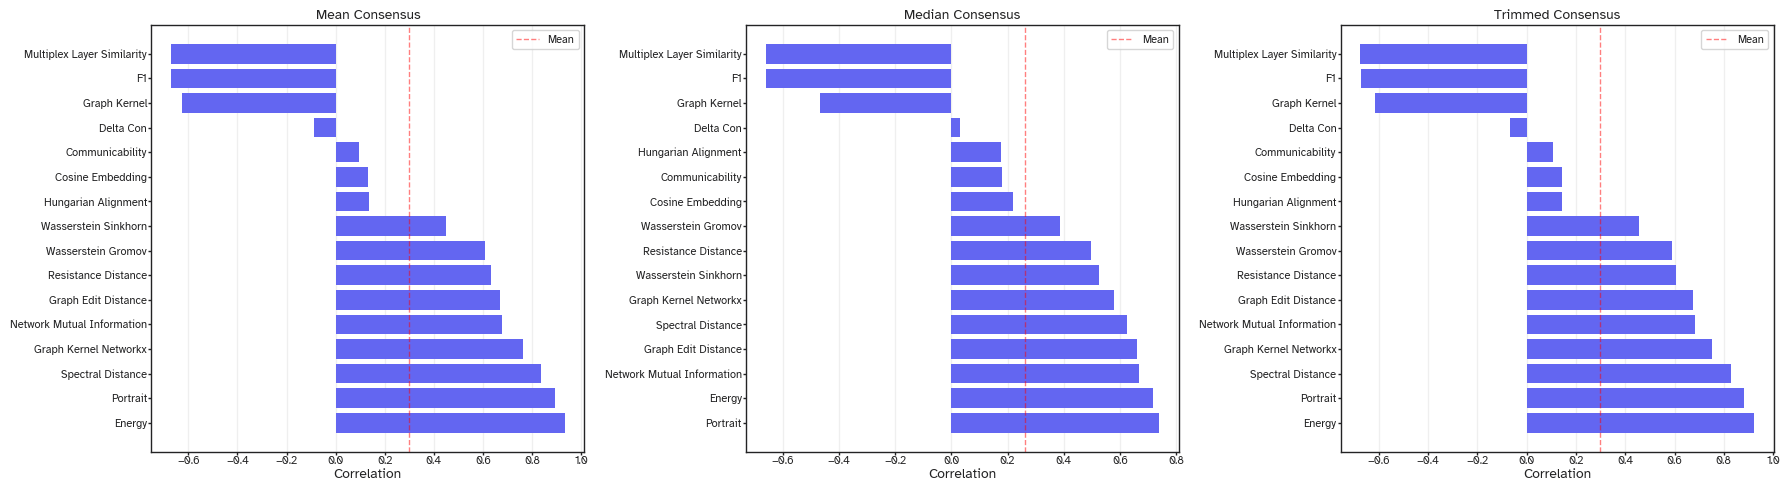


STRATEGY 2: INTER-METHOD AGREEMENT

Average agreement with other methods:
  energy                        : 0.2143
  portrait                      : 0.2058
  spectral_distance             : 0.1818
  graph_kernel_networkx         : 0.1676
  network_mutual_information    : 0.1510
  graph_edit_distance           : 0.1482
  resistance_distance           : 0.1453
  wasserstein_gromov            : 0.1224
  wasserstein_sinkhorn          : 0.0979
  hungarian_alignment           : -0.0046
  cosine_embedding              : -0.0066
  communicability               : -0.0276
  delta_con                     : -0.0859
  graph_kernel                  : -0.2517
  f1                            : -0.2815
  multiplex_layer_similarity    : -0.2819


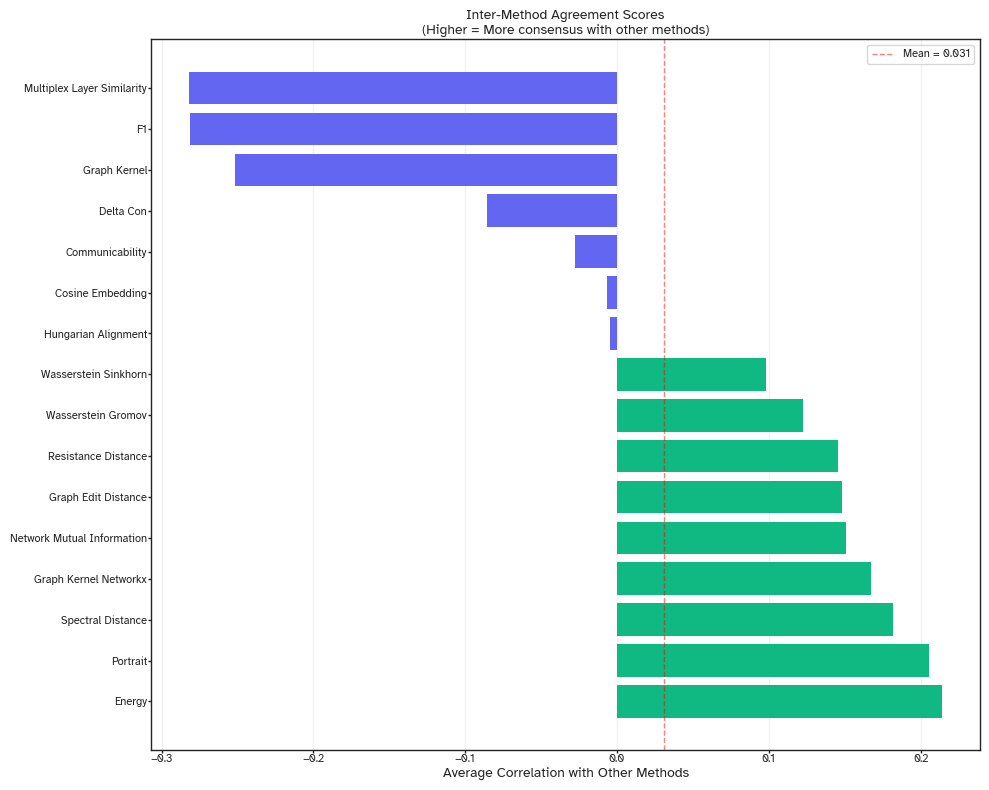


STRATEGY 3: PCA-BASED APPROACH

Explained variance by component:
  PC1: 0.4403 (44.03%)
  PC2: 0.1920 (19.20%)
  PC3: 0.0826 (8.26%)
  PC4: 0.0636 (6.36%)
  PC5: 0.0626 (6.26%)
  Cumulative (first 3): 0.7149

PC1 Loadings (main component):
  energy                        :  0.3365 (|0.3365|)
  portrait                      :  0.3317 (|0.3317|)
  network_mutual_information    :  0.3218 (|0.3218|)
  multiplex_layer_similarity    : -0.3215 (|0.3215|)
  graph_edit_distance           :  0.3213 (|0.3213|)
  f1                            : -0.3213 (|0.3213|)
  spectral_distance             :  0.2975 (|0.2975|)
  graph_kernel_networkx         :  0.2678 (|0.2678|)
  graph_kernel                  : -0.2511 (|0.2511|)
  resistance_distance           :  0.2472 (|0.2472|)
  wasserstein_sinkhorn          :  0.2044 (|0.2044|)
  wasserstein_gromov            :  0.1902 (|0.1902|)
  delta_con                     :  0.0275 (|0.0275|)
  communicability               : -0.0109 (|0.0109|)
  cosine_embeddin

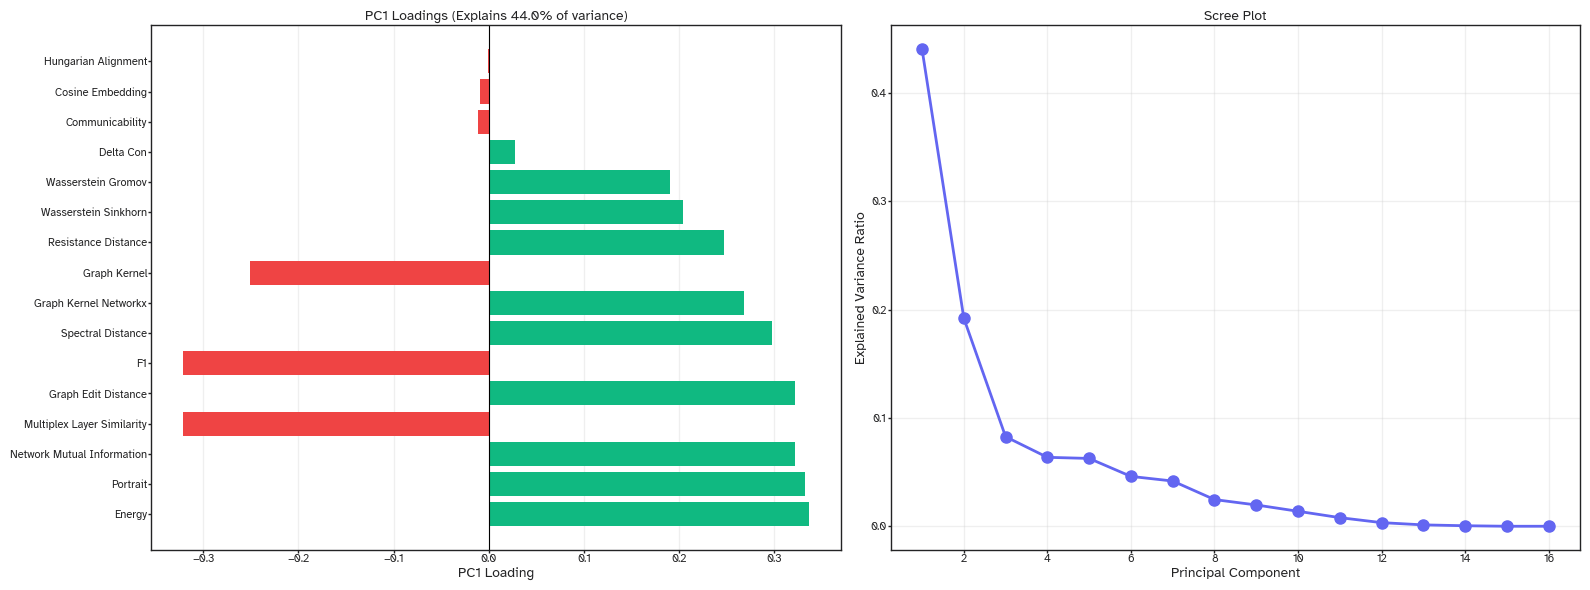


STRATEGY 4: STABILITY ANALYSIS

Stability metrics (lower = more stable/consistent):

Coefficient of Variation (CV):
  wasserstein_gromov            : 0.1944
  graph_kernel_networkx         : 0.2284
  wasserstein_sinkhorn          : 0.2310
  communicability               : 0.2925
  hungarian_alignment           : 0.2960
  cosine_embedding              : 0.3010
  graph_kernel                  : 0.3284
  network_mutual_information    : 0.3610
  resistance_distance           : 0.3665
  spectral_distance             : 0.3741
  f1                            : 0.3999
  multiplex_layer_similarity    : 0.4107
  graph_edit_distance           : 0.4286
  delta_con                     : 0.4350
  portrait                      : 0.4939
  energy                        : 0.5996


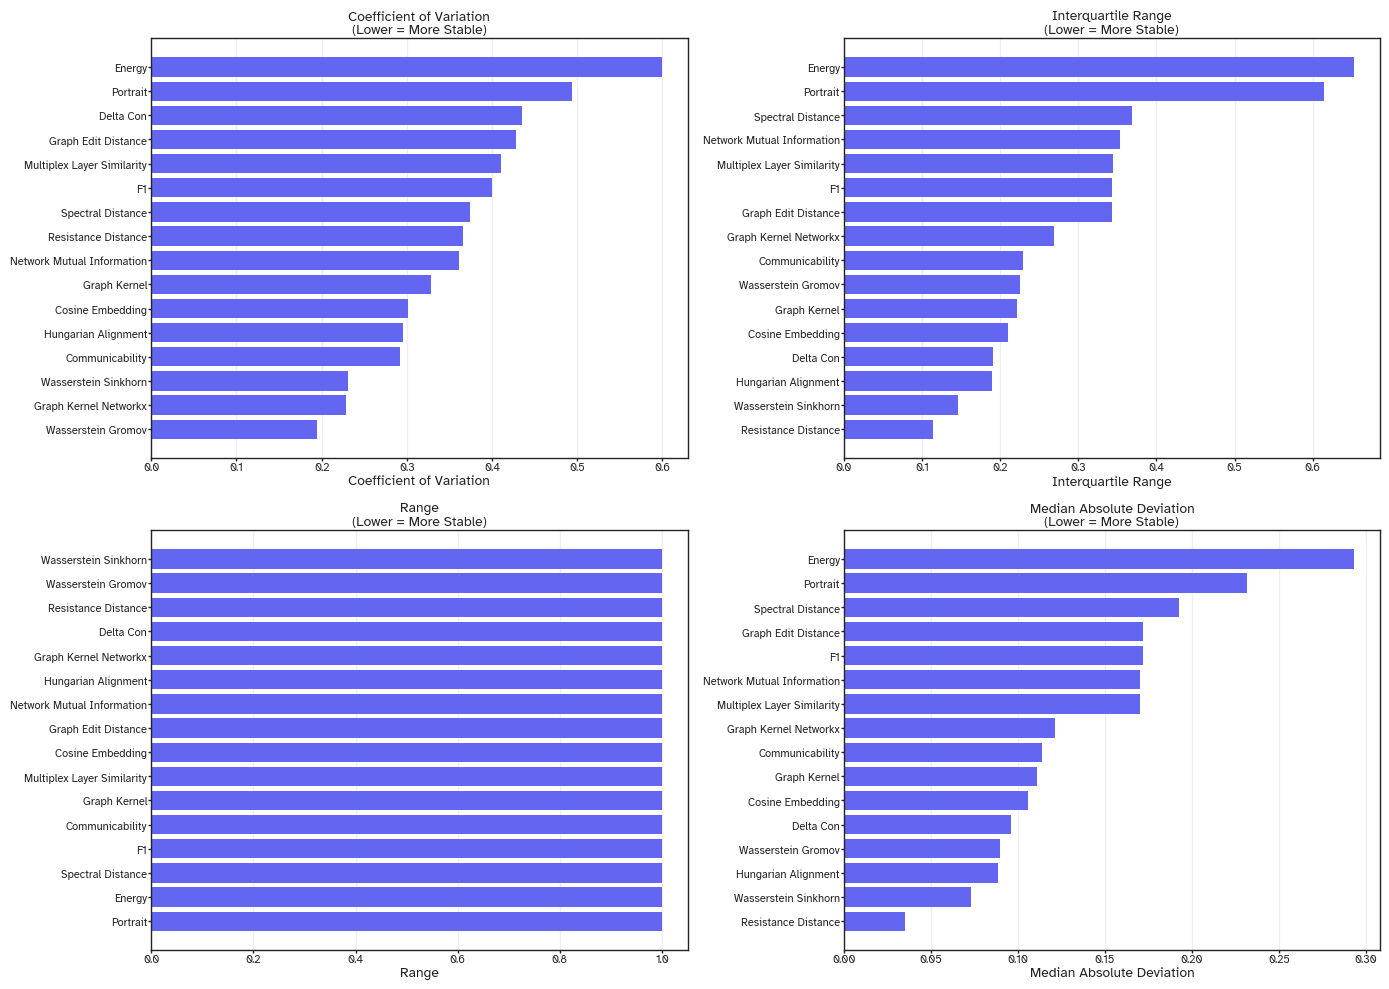


COMPREHENSIVE SUMMARY

FINAL RANKING (by composite score):
                            consensus_mean  consensus_median  inter_method_agreement  pc1_correlation  stability  composite_score  rank
graph_kernel_networkx             0.894175          0.885288                0.905932         0.795187   0.785555         0.853227   1.0
portrait                          0.975060          1.000000                0.982821         0.985519   0.105745         0.809829   2.0
energy                            1.000000          0.984672                1.000000         1.000000   0.000000         0.796934   3.0
spectral_distance                 0.939156          0.917806                0.934545         0.883746   0.296208         0.794292   4.0
network_mutual_information        0.841504          0.948194                0.872373         0.956133   0.324348         0.788510   5.0
wasserstein_gromov                0.796476          0.748601                0.814859         0.563526   1.000000         0.7

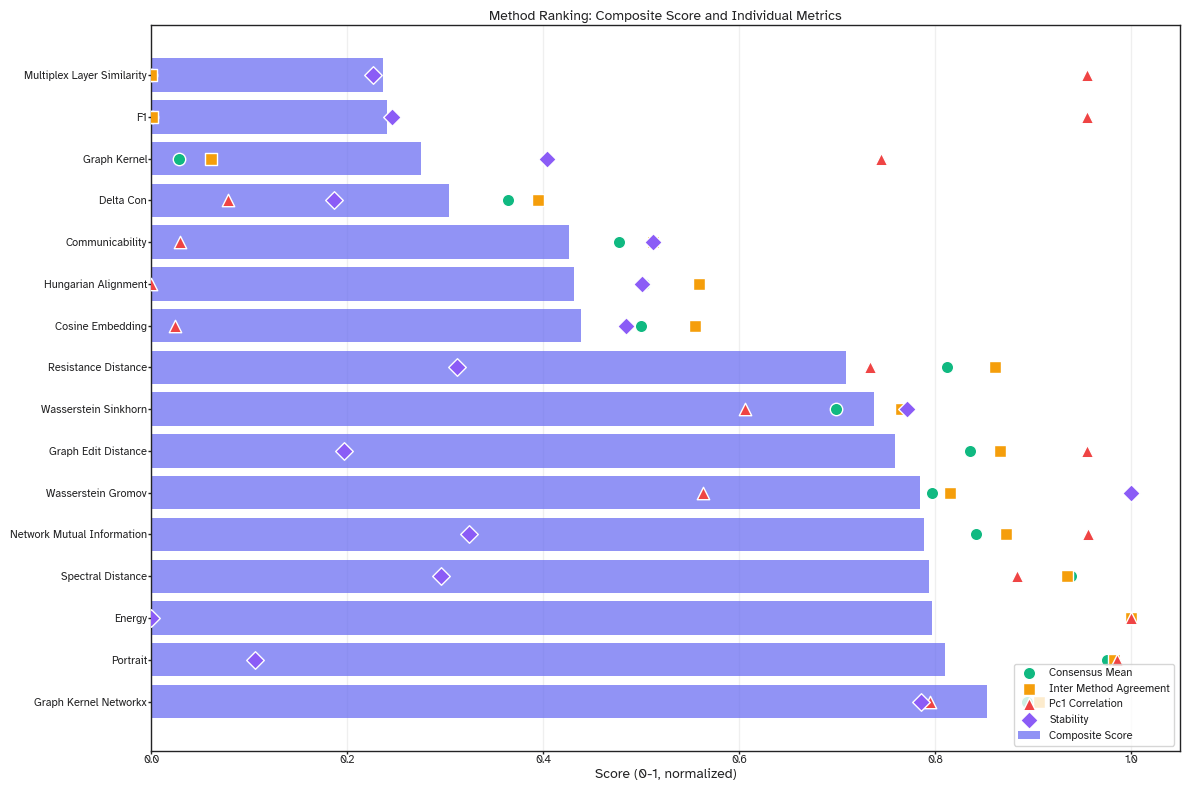


Analysis complete! All outputs saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/01_ring_sweep_animal_0/method_evaluation

Key insights:
1. Best overall method: graph_kernel_networkx
2. Top 3 methods: graph_kernel_networkx, portrait, energy
3. Check '/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/01_ring_sweep_animal_0/method_evaluation/method_ranking_summary.csv' for details


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Configuration"
output_path = Path(base_path) / "method_evaluation"
output_path.mkdir(exist_ok=True)

all_methods = [
    "portrait", "energy", "spectral_distance", "f1", "communicability",
    "graph_kernel", "multiplex_layer_similarity", "cosine_embedding",
    "graph_edit_distance", "network_mutual_information", "hungarian_alignment",
    "graph_kernel_networkx", "delta_con", "resistance_distance",
    "wasserstein_gromov", "wasserstein_sinkhorn"
]

def load_all_methods():
    """Load and combine all method data."""
    all_data_list = []
    loaded_methods = []
    
    for method in all_methods:
        path = f"{base_path}/summary_indiv_{method}_for_exp_{experiment_name}.csv"
        try:
            df = pd.read_csv(path)
            metric_cols = [col for col in df.columns 
                          if col not in ["eta", "gamma", "network_index", "filename", "id"]]
            if metric_cols:
                df['metric_value'] = df[metric_cols[0]]
                df['method'] = method
                all_data_list.append(df[['eta', 'gamma', 'id', 'metric_value', 'method']])
                loaded_methods.append(method)
                print(f"  ✓ Loaded {method}")
        except FileNotFoundError:
            print(f"  ✗ File not found for {method}")
    
    all_data = pd.concat(all_data_list, ignore_index=True)
    
    # Create wide format
    wide_data = all_data.pivot_table(
        index=['eta', 'gamma', 'id'],
        columns='method',
        values='metric_value'
    ).reset_index()
    
    return wide_data, loaded_methods


def normalize_methods(data, methods):
    """Normalize each method to [0, 1] range."""
    normalized = data.copy()
    for method in methods:
        min_val = data[method].min()
        max_val = data[method].max()
        if max_val > min_val:
            normalized[method] = (data[method] - min_val) / (max_val - min_val)
    return normalized


# ============================================================================
# STRATEGY 1: CONSENSUS-BASED APPROACHES
# ============================================================================

def consensus_approaches(data, methods):
    """Calculate different consensus measures."""
    print("\n" + "="*70)
    print("STRATEGY 1: CONSENSUS-BASED GROUND TRUTH")
    print("="*70)
    
    results = {}
    
    # Normalize first
    norm_data = normalize_methods(data, methods)
    
    # 1. Mean consensus (ensemble average)
    norm_data['consensus_mean'] = norm_data[methods].mean(axis=1)
    
    # 2. Median consensus (robust to outliers)
    norm_data['consensus_median'] = norm_data[methods].median(axis=1)
    
    # 3. Trimmed mean (remove top/bottom 10%)
    norm_data['consensus_trimmed'] = norm_data[methods].apply(
        lambda x: stats.trim_mean(x.dropna(), 0.1), axis=1
    )
    
    # Calculate correlations with each consensus
    for consensus_type in ['mean', 'median', 'trimmed']:
        col = f'consensus_{consensus_type}'
        print(f"\nCorrelations with {consensus_type.upper()} consensus:")
        corrs = {}
        for method in methods:
            corr = norm_data[method].corr(norm_data[col])
            corrs[method] = corr
            print(f"  {method:30s}: {corr:.4f}")
        results[consensus_type] = corrs
    
    # Save
    consensus_df = pd.DataFrame(results).T
    consensus_df.to_csv(output_path / 'consensus_correlations.csv')
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for idx, consensus_type in enumerate(['mean', 'median', 'trimmed']):
        corrs = results[consensus_type]
        sorted_methods = sorted(corrs.keys(), key=lambda x: corrs[x], reverse=True)
        values = [corrs[m] for m in sorted_methods]
        
        axes[idx].barh(range(len(sorted_methods)), values, color='#6366f1')
        axes[idx].set_yticks(range(len(sorted_methods)))
        axes[idx].set_yticklabels([m.replace('_', ' ').title() for m in sorted_methods], fontsize=8)
        axes[idx].set_xlabel('Correlation', fontsize=10)
        axes[idx].set_title(f'{consensus_type.title()} Consensus') # , fontsize=12, fontweight='bold')
        axes[idx].axvline(x=np.mean(values), color='red', linestyle='--', alpha=0.5, label='Mean')
        axes[idx].grid(axis='x', alpha=0.3)
        axes[idx].legend()
    
    plt.tight_layout()
    plt.savefig(output_path / 'consensus_correlations.png', dpi=300, bbox_inches='tight')
    # plt.close()
    plt.show()
    
    return norm_data, results


# ============================================================================
# STRATEGY 2: INTER-METHOD AGREEMENT
# ============================================================================

def inter_method_agreement(data, methods):
    """Calculate how well each method agrees with all others."""
    print("\n" + "="*70)
    print("STRATEGY 2: INTER-METHOD AGREEMENT")
    print("="*70)
    
    norm_data = normalize_methods(data, methods)
    
    # Calculate average correlation with all other methods
    agreement_scores = {}
    for method1 in methods:
        corrs = []
        for method2 in methods:
            if method1 != method2:
                corr = norm_data[method1].corr(norm_data[method2])
                if not np.isnan(corr):
                    corrs.append(corr)
        agreement_scores[method1] = np.mean(corrs) if corrs else 0
    
    print("\nAverage agreement with other methods:")
    for method, score in sorted(agreement_scores.items(), key=lambda x: x[1], reverse=True):
        print(f"  {method:30s}: {score:.4f}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    sorted_methods = sorted(agreement_scores.keys(), key=lambda x: agreement_scores[x], reverse=True)
    values = [agreement_scores[m] for m in sorted_methods]
    
    colors = ['#10b981' if v > np.mean(values) else '#6366f1' for v in values]
    ax.barh(range(len(sorted_methods)), values, color=colors)
    ax.set_yticks(range(len(sorted_methods)))
    ax.set_yticklabels([m.replace('_', ' ').title() for m in sorted_methods]) # , fontsize=9)
    ax.set_xlabel('Average Correlation with Other Methods') # , fontsize=11)
    ax.set_title('Inter-Method Agreement Scores\n(Higher = More consensus with other methods)') 
                #  fontsize=13, fontweight='bold', pad=15)
    ax.axvline(x=np.mean(values), color='red', linestyle='--', alpha=0.5, label=f'Mean = {np.mean(values):.3f}')
    ax.grid(axis='x', alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(output_path / 'inter_method_agreement.png', dpi=300, bbox_inches='tight')
    # plt.close()
    plt.show()
    
    pd.DataFrame({'method': list(agreement_scores.keys()), 
                  'agreement_score': list(agreement_scores.values())}).to_csv(
        output_path / 'inter_method_agreement.csv', index=False)
    
    return agreement_scores


# ============================================================================
# STRATEGY 3: PCA-BASED APPROACH
# ============================================================================

def pca_approach(data, methods):
    """Use PCA to find the main component across methods."""
    print("\n" + "="*70)
    print("STRATEGY 3: PCA-BASED APPROACH")
    print("="*70)
    
    norm_data = normalize_methods(data, methods)
    
    # Prepare data (remove NaNs)
    X = norm_data[methods].dropna()
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    
    print(f"\nExplained variance by component:")
    for i, var in enumerate(pca.explained_variance_ratio_[:5]):
        print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
    print(f"  Cumulative (first 3): {pca.explained_variance_ratio_[:3].sum():.4f}")
    
    # Loadings (how much each method contributes to PC1)
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(len(methods))],
        index=methods
    )
    
    print(f"\nPC1 Loadings (main component):")
    for method, loading in loadings['PC1'].abs().sort_values(ascending=False).items():
        print(f"  {method:30s}: {loadings.loc[method, 'PC1']:7.4f} (|{loading:.4f}|)")
    
    # Save
    loadings.to_csv(output_path / 'pca_loadings.csv')
    
    # Plot loadings
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # PC1 loadings
    sorted_methods = loadings['PC1'].abs().sort_values(ascending=False).index
    values = [loadings.loc[m, 'PC1'] for m in sorted_methods]
    colors = ['#10b981' if v > 0 else '#ef4444' for v in values]
    
    axes[0].barh(range(len(sorted_methods)), values, color=colors)
    axes[0].set_yticks(range(len(sorted_methods)))
    axes[0].set_yticklabels([m.replace('_', ' ').title() for m in sorted_methods]) # , fontsize=9)
    axes[0].set_xlabel('PC1 Loading') # , fontsize=11)
    axes[0].set_title(f'PC1 Loadings (Explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance)') # , 
                        # fontsize=12, fontweight='bold')
    axes[0].axvline(x=0, color='black', linewidth=0.8)
    axes[0].grid(axis='x', alpha=0.3)
    
    # Scree plot
    axes[1].plot(range(1, len(pca.explained_variance_ratio_) + 1), 
                 pca.explained_variance_ratio_, 'o-', linewidth=2, markersize=8, color='#6366f1')
    axes[1].set_xlabel('Principal Component') # , fontsize=11)
    axes[1].set_ylabel('Explained Variance Ratio') # , fontsize=11)
    axes[1].set_title('Scree Plot') # , fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_path / 'pca_analysis.png', dpi=300, bbox_inches='tight')
    # plt.close()
    plt.show()
    
    # Calculate correlation of each method with PC1
    pc1_scores = X_pca[:, 0]
    pc1_correlations = {}
    for i, method in enumerate(methods):
        pc1_correlations[method] = np.corrcoef(X[method], pc1_scores)[0, 1]
    
    return loadings, pca, pc1_correlations


# ============================================================================
# STRATEGY 4: COEFFICIENT OF VARIATION (STABILITY)
# ============================================================================

def stability_analysis(data, methods):
    """Analyze which methods have more stable/consistent values."""
    print("\n" + "="*70)
    print("STRATEGY 4: STABILITY ANALYSIS")
    print("="*70)
    
    norm_data = normalize_methods(data, methods)
    
    stability_metrics = {}
    
    for method in methods:
        values = norm_data[method].dropna()
        stability_metrics[method] = {
            'cv': values.std() / values.mean() if values.mean() != 0 else np.inf,  # Coefficient of variation
            'iqr': values.quantile(0.75) - values.quantile(0.25),  # Interquartile range
            'range': values.max() - values.min(),
            'mad': np.median(np.abs(values - values.median()))  # Median absolute deviation
        }
    
    print("\nStability metrics (lower = more stable/consistent):")
    print("\nCoefficient of Variation (CV):")
    for method, metrics in sorted(stability_metrics.items(), key=lambda x: x[1]['cv']):
        print(f"  {method:30s}: {metrics['cv']:.4f}")
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    for idx, (metric_name, ylabel) in enumerate([
        ('cv', 'Coefficient of Variation'),
        ('iqr', 'Interquartile Range'),
        ('range', 'Range'),
        ('mad', 'Median Absolute Deviation')
    ]):
        ax = axes[idx // 2, idx % 2]
        
        sorted_methods = sorted(stability_metrics.keys(), 
                               key=lambda x: stability_metrics[x][metric_name])
        values = [stability_metrics[m][metric_name] for m in sorted_methods]
        
        ax.barh(range(len(sorted_methods)), values, color='#6366f1')
        ax.set_yticks(range(len(sorted_methods)))
        ax.set_yticklabels([m.replace('_', ' ').title() for m in sorted_methods], fontsize=8)
        ax.set_xlabel(ylabel) # , fontsize=10)
        ax.set_title(f'{ylabel}\n(Lower = More Stable)') # , fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_path / 'stability_analysis.png', dpi=300, bbox_inches='tight')
    # plt.close() 
    plt.show()
    
    pd.DataFrame(stability_metrics).T.to_csv(output_path / 'stability_metrics.csv')
    
    return stability_metrics


# ============================================================================
# SUMMARY REPORT
# ============================================================================

def create_summary_report(consensus_results, agreement_scores, pc1_correlations, stability_metrics):
    """Create a comprehensive summary ranking methods."""
    print("\n" + "="*70)
    print("COMPREHENSIVE SUMMARY")
    print("="*70)
    
    methods = list(agreement_scores.keys())
    
    summary = pd.DataFrame(index=methods)
    
    # Add consensus correlations
    summary['consensus_mean'] = [consensus_results['mean'][m] for m in methods]
    summary['consensus_median'] = [consensus_results['median'][m] for m in methods]
    
    # Add inter-method agreement
    summary['inter_method_agreement'] = [agreement_scores[m] for m in methods]
    
    # Add PC1 correlation (absolute value)
    summary['pc1_correlation'] = [abs(pc1_correlations[m]) for m in methods]
    
    # Add stability (inverse CV, so higher = better)
    summary['stability'] = [1 / (stability_metrics[m]['cv'] + 0.01) for m in methods]
    
    # Normalize all metrics to [0, 1]
    for col in summary.columns:
        min_val = summary[col].min()
        max_val = summary[col].max()
        if max_val > min_val:
            summary[col] = (summary[col] - min_val) / (max_val - min_val)
    
    # Calculate composite score (equal weighting)
    summary['composite_score'] = summary.mean(axis=1)
    
    # Rank
    summary['rank'] = summary['composite_score'].rank(ascending=False)
    
    # Sort by composite score
    summary = summary.sort_values('composite_score', ascending=False)
    
    print("\nFINAL RANKING (by composite score):")
    print(summary.to_string())
    
    summary.to_csv(output_path / 'method_ranking_summary.csv')
    
    # Visualization
    fig, ax = plt.subplots(figsize=(12, 8))
    
    sorted_methods = summary.index
    y_pos = range(len(sorted_methods))
    
    ax.barh(y_pos, summary['composite_score'], color='#6366f1', alpha=0.7, label='Composite Score')
    
    # Add individual metric markers
    for col, marker, color in [
        ('consensus_mean', 'o', '#10b981'),
        ('inter_method_agreement', 's', '#f59e0b'),
        ('pc1_correlation', '^', '#ef4444'),
        ('stability', 'D', '#8b5cf6')
    ]:
        ax.scatter(summary[col], y_pos, marker=marker, s=80, 
                  color=color, label=col.replace('_', ' ').title(), 
                  edgecolors='white', linewidth=1, zorder=3)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels([m.replace('_', ' ').title() for m in sorted_methods]) # , fontsize=9)
    ax.set_xlabel('Score (0-1, normalized)') # , fontsize=11)
    ax.set_title('Method Ranking: Composite Score and Individual Metrics') # , 
                # fontsize=13, fontweight='bold', pad=15)
    ax.legend(loc='lower right') # , fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_path / 'method_ranking_summary.png', dpi=300, bbox_inches='tight')
    # plt.close()
    plt.show()
    
    return summary


def main():
    print("="*70)
    print("COMPREHENSIVE METHOD EVALUATION")
    print("="*70)
    
    # Load data
    print("\nLoading data...")
    data, methods = load_all_methods()
    print(f"\nLoaded {len(methods)} methods with {len(data)} networks")
    
    # Run all strategies
    norm_data, consensus_results = consensus_approaches(data, methods)
    agreement_scores = inter_method_agreement(data, methods)
    loadings, pca_model, pc1_correlations = pca_approach(data, methods)
    stability_metrics = stability_analysis(data, methods)
    
    # Create summary
    summary = create_summary_report(consensus_results, agreement_scores, 
                                   pc1_correlations, stability_metrics)
    
    print(f"\n{'='*70}")
    print(f"Analysis complete! All outputs saved to: {output_path}")
    print(f"{'='*70}")
    print("\nKey insights:")
    print(f"1. Best overall method: {summary.index[0]}")
    print(f"2. Top 3 methods: {', '.join(summary.index[:3])}")
    print(f"3. Check '{output_path}/method_ranking_summary.csv' for details")

if __name__ == "__main__":
    main()